# Milestone 3 - Modelação e Avaliação (Objetivo 2)

Neste notebook é desenvolvido um índice de risco de abandono (`Attrition`), com base nas probabilidades previstas por modelos de classificação supervisionada. Numa fase inicial, foram testados e comparados diferentes algoritmos preditivos, tendo sido selecionada a **Regressão Logística** como modelo final, devido ao seu equilíbrio entre desempenho, estabilidade e interpretabilidade. Posteriormente, o modelo foi otimizado através de *tuning* de hiperparâmetros, permitindo melhorar a sua capacidade de identificação de colaboradores em risco e garantir uma utilização eficaz em contexto de negócio.

Esta etapa enquadra-se nas fases de *Modelling* e *Evaluation* da metodologia CRISP-DM, tendo como objetivo transformar previsões probabilísticas em **informação acionável para suporte à decisão em contexto de negócio**.

Ao contrário de uma abordagem puramente classificativa, este notebook foca-se na **utilização das probabilidades previstas**, permitindo uma análise mais granular do risco individual de cada colaborador.

---

## Estrutura da Análise

Foram consideradas diferentes versões do modelo de Regressão Logística:

- **Baseline:** Regressão Logística 
- **Candidato 1:** Naive Bayes
- **Candidato 2:** LDA (Linear Discriminant Analysis)
- **Candidato 3:** KNN (K-Nearest Neighbors)
- **Candidato 4:** Extra Trees
- **Candidato 5:** SVM (Support Vector Machine)
- **Candidato 6:** ADABOOST
- **Candidato 7:** LIGHTGBM (Light Gradient Boosting Machine)
- **Candidato 8:** XGBOOST
- **Candidato 9:** Random Forest
---

## Metodologia

A análise segue os seguintes passos principais:

- Preparação e normalização dos dados (StandardScaler)
- Divisão do dataset em treino e teste (80/20)
- Treino dos modelos e avaliação do desempenho
- Escolha do modelo com melhor desempenho
- Otimização dos hiperparâmetros através de validação cruzada estratificada

- **retificar daqui para baixo**

- Avaliação do modelo otimizado em dados de teste
- **Otimização do threshold de decisão**, com base na maximização do F1-score
- Comparação entre baseline, modelo otimizado e modelo com threshold ajustado
- Geração das probabilidades de saída para todos os colaboradores;
- Construção de um índice de risco categórico
- Análise da distribuição das probabilidades e dos níveis de risco
- Caracterização dos perfis associados a cada categoria de risco
- Avaliação da coerência entre o índice de risco e a variável real (*Attrition*)
- Interpretação dos resultados numa perspetiva de negócio

---

## Definição do Índice de Risco

Com base nas probabilidades previstas, os colaboradores são classificados nas seguintes categorias:

- **Risco Baixo:** probabilidade < 30%  
- **Risco Médio:** 30% ≤ probabilidade < 50%  
- **Risco Alto:** 50% ≤ probabilidade < 70%  
- **Risco Crítico:** probabilidade ≥ 70%  

Esta segmentação permite transformar uma variável contínua em **grupos interpretáveis e acionáveis**, facilitando a priorização de intervenções por parte da gestão de recursos humanos.

---

## Métricas de Avaliação

O desempenho dos modelos é avaliado com base em métricas adequadas a problemas de classificação com classes desbalanceadas:

- **F1-Score** → métrica principal (equilíbrio entre precision e recall);  
- **Recall** → capacidade de identificar colaboradores em risco de saída;  
- **Precision** → controlo de falsos positivos;  
- **AUC-ROC** → capacidade discriminativa global do modelo.

---

## Objetivo Final

Construir um índice de risco robusto e interpretável que permita:

- Identificar colaboradores com maior probabilidade de saída
- Apoiar decisões estratégicas de retenção de talento
- Priorizar intervenções com base no nível de risco
- Traduzir resultados analíticos em **insights de negócio acionáveis**.

---

**Autores:** Luís Figueira, Martim Ferreira e Mateus Afonso

# Índice de Risco - Regressão Logística (Baseline)
Modelo de Regressão Logística com StandardScaler e classificação de risco.

In [1]:
# 1. IMPORTAÇÕES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, RocCurveDisplay,
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")
print("Bibliotecas importadas com sucesso.")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Bibliotecas importadas com sucesso.


In [2]:
# 2. CARREGAMENTO DO DATASET

#url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
#df = pd.read_csv(url)
#print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

In [3]:
# 3. PREPARAÇÃO DAS FEATURES

#cols_remover = ["Attrition", "OverTime", "Gender",
#                "BusinessTravel", "Department", "EducationField",
#                "JobRole", "MaritalStatus"]

#cols_remover = [c for c in cols_remover if c in df.columns]
#df_model = df.drop(columns=cols_remover)

#TARGET = "Attrition_bin"
#X = df_model.drop(columns=[TARGET])
#y = df_model[TARGET]
#X = X.select_dtypes(include=[np.number])

#print(f"Features utilizadas: {X.shape[1]}")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

In [4]:
# 4. DIVISÃO TREINO / TESTE — Gerar
#import os
#import zipfile
#from IPython.display import FileLink, display

#treino_path = "data/processed/Objetivo2/treino"
#teste_path  = "data/processed/Objetivo2/teste"

# 80% treino, 20% teste
# stratify=y — garante a mesma proporção de Yes/No em treino e teste
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42, stratify=y
#)

# Criar as pastas e guardar os splits
#os.makedirs(treino_path, exist_ok=True)
#os.makedirs(teste_path, exist_ok=True)
#X_train.to_csv(f"{treino_path}/X_train.csv", index=False)
#y_train.to_csv(f"{treino_path}/y_train.csv", index=False)
#X_test.to_csv(f"{teste_path}/X_test.csv", index=False)
#y_test.to_csv(f"{teste_path}/y_test.csv", index=False)

# Criar ZIP com a estrutura de pastas completa
#zip_path = "data/processed/Objetivo2/splits.zip"
#with zipfile.ZipFile(zip_path, "w") as zipf:
#    zipf.write(f"{treino_path}/X_train.csv", "treino/X_train.csv")
#    zipf.write(f"{treino_path}/y_train.csv", "treino/y_train.csv")
#    zipf.write(f"{teste_path}/X_test.csv",   "teste/X_test.csv")
#    zipf.write(f"{teste_path}/y_test.csv",   "teste/y_test.csv")

#print("Splits gerados! :")
#display(FileLink(zip_path))
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

In [5]:
# 4. DIVISÃO TREINO / TESTE — CARREGAR DO GITHUB
base_treino = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo2/treino"
base_teste  = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo2/teste"

# Carregar diretamente do GitHub
X_train = pd.read_csv(f"{base_treino}/X_train.csv")
y_train = pd.read_csv(f"{base_treino}/y_train.csv").squeeze()
X_test  = pd.read_csv(f"{base_teste}/X_test.csv")
y_test  = pd.read_csv(f"{base_teste}/y_test.csv").squeeze()

print(f"Treino: {X_train.shape[0]} obs | Teste: {X_test.shape[0]} obs")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Treino: 1176 obs | Teste: 294 obs


In [6]:
# 5. TREINO — REGRESSÃO LOGÍSTICA (BASELINE)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression())
])

pipeline.fit(X_train, y_train)
print("Modelo treinado.")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Modelo treinado.


In [7]:
# 6. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }
    # Autores: Figueira, L., Afonso, M. e Ferreira, M.

In [8]:
# 6.1 TREINO
r_treino = avaliar_modelo(pipeline, X_train, y_train, "Treino")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

===== METRICAS — Treino =====
  F1-Score:  0.6519
  Precision: 0.8175
  Recall:    0.5421
  AUC-ROC:   0.8819

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       986
        Saiu       0.82      0.54      0.65       190

    accuracy                           0.91      1176
   macro avg       0.87      0.76      0.80      1176
weighted avg       0.90      0.91      0.90      1176



In [9]:
# 6.2 TESTE
r_teste = avaliar_modelo(pipeline, X_test, y_test, "Teste")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

===== METRICAS — Teste =====
  F1-Score:  0.4595
  Precision: 0.6296
  Recall:    0.3617
  AUC-ROC:   0.8170

              precision    recall  f1-score   support

  Permaneceu       0.89      0.96      0.92       247
        Saiu       0.63      0.36      0.46        47

    accuracy                           0.86       294
   macro avg       0.76      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294



In [10]:
# 7. COMPARAÇÃO TREINO vs TESTE

print("===== COMPARAÇÃO TREINO vs TESTE =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*42}")
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = r_treino[metrica]
    val_teste  = r_teste[metrica]
    diff       = val_treino - val_teste
    nome       = metrica.upper() if metrica != "acc" else "Accuracy"
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

diff_f1 = r_treino["f1"] - r_teste["f1"]
if diff_f1 > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")
    # Autores: Figueira, L., Afonso, M. e Ferreira, M.

===== COMPARAÇÃO TREINO vs TESTE =====
  Métrica         Treino     Teste   Diferença
  ------------------------------------------
  Accuracy        0.9065    0.8639     +0.0425
  PRECISION       0.8175    0.6296     +0.1878
  RECALL          0.5421    0.3617     +0.1804
  F1              0.6519    0.4595     +0.1924
  AUC             0.8819    0.8170     +0.0649
  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


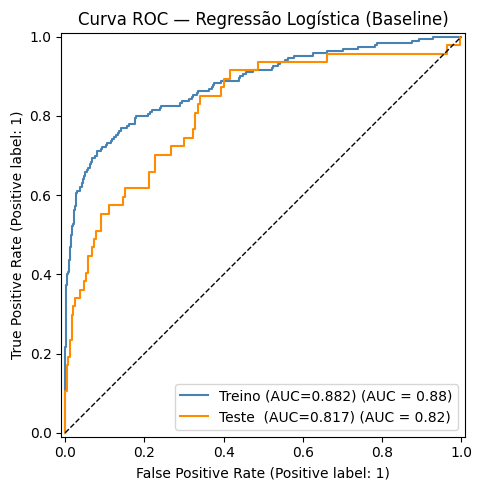

In [11]:
# 8. CURVA ROC — TREINO E TESTE

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    r_treino["y"], r_treino["y_proba"],
    name=f"Treino (AUC={r_treino['auc']:.3f})", ax=ax, color="steelblue"
)
RocCurveDisplay.from_predictions(
    r_teste["y"], r_teste["y_proba"],
    name=f"Teste  (AUC={r_teste['auc']:.3f})", ax=ax, color="darkorange"
)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Curva ROC — Regressão Logística (Baseline)")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste.png", dpi=150, bbox_inches="tight")
plt.show()
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

In [12]:
# 9. GERAR PROBABILIDADES DE SAÍDA (dataset completo)
url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features que fizeste no início
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"])
X_completo = X_completo.select_dtypes(include=[np.number])

df_risco = df_completo.copy()
df_risco["prob_saida"] = pipeline.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco)} colaboradores.")
print(df_risco["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

Probabilidades geradas para 1470 colaboradores.
count    1470.0000
mean        0.1591
std         0.2222
min         0.0000
25%         0.0132
50%         0.0598
75%         0.2057
90%         0.5180
max         0.9932
Name: prob_saida, dtype: float64


In [13]:
# 10. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

df_risco["nivel_risco"] = df_risco["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem = df_risco["nivel_risco"].value_counts()
percentagem = df_risco["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n = contagem.get(cat, 0)
    pct = percentagem.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")
# Autores: Figueira, L., Afonso, M. e Ferreira, M.


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo          1217        82.8%
Médio           100         6.8%
Alto             81         5.5%
Crítico          72         4.9%


In [14]:
# 11. ANÁLISE POR CATEGORIA DE RISCO

cols_analise = ["prob_saida", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
            "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"]:
    if col in df_risco.columns:
        cols_analise.append(col)

print("\n===== PERFIL MEDIO POR CATEGORIA DE RISCO =====")
perfil = df_risco.groupby("nivel_risco")[cols_analise].mean().reindex(ORDEM).round(3)
display(perfil)
# Autores: Figueira, L., Afonso, M. e Ferreira, M.


===== PERFIL MEDIO POR CATEGORIA DE RISCO =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.071,0.065,37.969,6977.157,2.177,12.175,0.214,2.217,7.604
Médio,0.388,0.380,33.150,4244.720,1.560,7.480,0.580,1.950,4.650
Alto,0.592,0.654,31.444,4498.259,1.568,7.420,0.630,1.988,4.741
Crítico,0.847,0.931,30.667,3878.861,1.417,5.764,0.653,1.792,2.764


In [15]:
# 12. TOP 20 COLABORADORES COM MAIOR RISCO

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco.columns:
        cols_top.append(col)

top20 = df_risco.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAIDA =====")
display(top20)
# Autores: Figueira, L., Afonso, M. e Ferreira, M.


===== TOP 20 — MAIOR PROBABILIDADE DE SAIDA =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.993184,Crítico,1,26,2340,1,1
1,0.992612,Crítico,1,25,1118,1,1
2,0.984904,Crítico,1,24,3172,1,1
3,0.981745,Crítico,1,18,1878,1,1
4,0.980088,Crítico,1,21,2174,1,1
5,0.978946,Crítico,1,32,2795,1,1
6,0.960832,Crítico,1,19,1675,1,1
7,0.953581,Crítico,1,19,2325,1,0
8,0.951764,Crítico,1,19,2121,1,1
9,0.950460,Crítico,1,27,2863,1,0


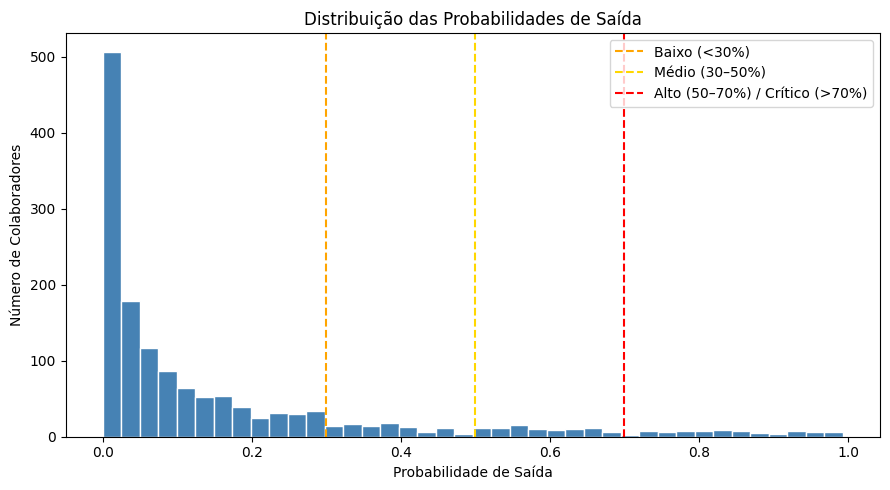

In [16]:
# 13. VISUALIZAÇÕES DO ÍNDICE DE RISCO

# 13.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_risco["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Novos thresholds
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Baixo (<30%)")
ax.axvline(0.50, color="gold", linestyle="--", linewidth=1.5, label="Médio (30–50%)")
ax.axvline(0.70, color="red", linestyle="--", linewidth=1.5, label="Alto (50–70%) / Crítico (>70%)")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída")

ax.legend()
plt.tight_layout()
plt.savefig("distribuicao_probabilidades.png", dpi=150, bbox_inches="tight")
plt.show()
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

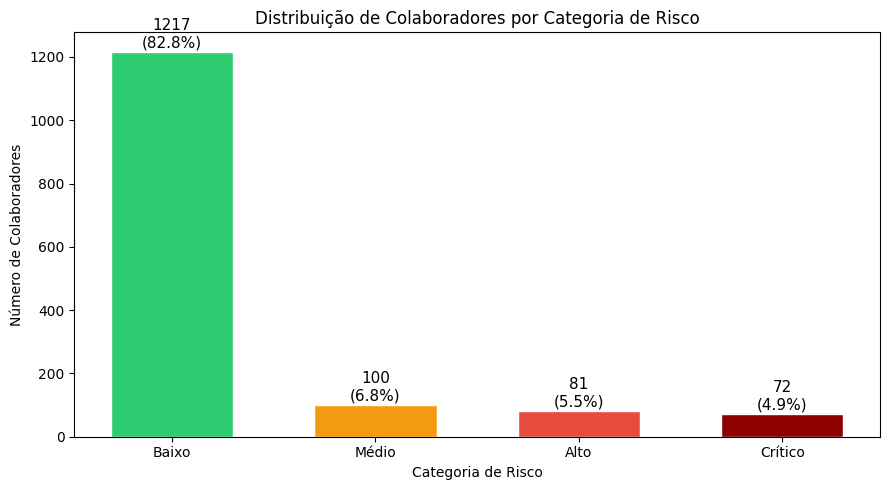

In [17]:
# 13.2 Contagem por categoria (ATUALIZADO)

# Nova ordem e cores coerentes com risco
ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = {
    "Baixo": "#2ecc71",     # verde
    "Médio": "#f39c12",     # laranja
    "Alto": "#e74c3c",      # vermelho
    "Crítico": "#8e0000"    # vermelho escuro
}

fig, ax = plt.subplots(figsize=(9, 5))

vals = [contagem.get(c, 0) for c in ORDEM]
bars = ax.bar(
    ORDEM,
    vals,
    color=[cores[c] for c in ORDEM],
    edgecolor="white",
    width=0.6
)

# Labels com contagem + %
for bar, cat in zip(bars, ORDEM):
    n = contagem.get(cat, 0)
    pct = percentagem.get(cat, 0.0)

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição de Colaboradores por Categoria de Risco")

plt.tight_layout()
plt.savefig("categorias_risco.png", dpi=150, bbox_inches="tight")
plt.show()
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

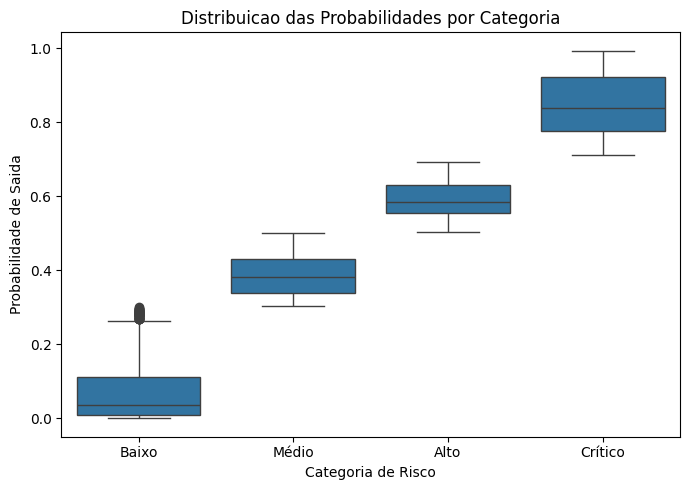

In [18]:
# 13.3 Boxplot por categoria
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_risco, x="nivel_risco", y="prob_saida", order=ORDEM, ax=ax)
ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saida")
ax.set_title("Distribuicao das Probabilidades por Categoria")
plt.tight_layout()
plt.savefig("boxplot_risco.png", dpi=150, bbox_inches="tight")
plt.show()
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

In [19]:
# 14. RESUMO FINAL

print("=" * 55)
print("RESUMO — BASELINE")
print("=" * 55)

print(f"  Modelo:        Regressão Logística (parâmetros default)")
print(f"  Colaboradores: {len(df_risco)}")

print(f"\n  {'Métrica':<12} {'Treino':>8} {'Teste':>8}")
print("-" * 32)
for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"  {nome:<12} {r_treino[metrica]:>8.4f} {r_teste[metrica]:>8.4f}")

print("\n  Distribuição das categorias de risco:")
print(f"  Baixo:    prob < 30%        -> {contagem.get('Baixo', 0)} colaboradores")
print(f"  Médio:    30% ≤ prob < 50%  -> {contagem.get('Médio', 0)} colaboradores")
print(f"  Alto:     50% ≤ prob < 70%  -> {contagem.get('Alto', 0)} colaboradores")
print(f"  Crítico:  prob ≥ 70%        -> {contagem.get('Crítico', 0)} colaboradores")

print("=" * 55)
# Autores: Figueira, L., Afonso, M. e Ferreira, M.

RESUMO — BASELINE
  Modelo:        Regressão Logística (parâmetros default)
  Colaboradores: 1470

  Métrica        Treino    Teste
--------------------------------
  Accuracy       0.9065   0.8639
  Precision      0.8175   0.6296
  Recall         0.5421   0.3617
  F1-Score       0.6519   0.4595
  AUC-ROC        0.8819   0.8170

  Distribuição das categorias de risco:
  Baixo:    prob < 30%        -> 1217 colaboradores
  Médio:    30% ≤ prob < 50%  -> 100 colaboradores
  Alto:     50% ≤ prob < 70%  -> 81 colaboradores
  Crítico:  prob ≥ 70%        -> 72 colaboradores


#  Treino e Avaliação Comparativa do Desempenho de Modelos Candidatos


## 1. Candidato - Naive Bayes


In [20]:
# 15. TREINO — NAIVE BAYES
pipeline_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

pipeline_nb.fit(X_train, y_train)
print("Modelo Naive Bayes treinado.")

Modelo Naive Bayes treinado.


In [21]:
# 16. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (NAIVE BAYES)

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [22]:
# 16.1 TREINO
resultados_treino_nb = avaliar_modelo(pipeline_nb, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.4294
  Precision: 0.3004
  Recall:    0.7526
  AUC-ROC:   0.7768

              precision    recall  f1-score   support

  Permaneceu       0.93      0.66      0.77       986
        Saiu       0.30      0.75      0.43       190

    accuracy                           0.68      1176
   macro avg       0.62      0.71      0.60      1176
weighted avg       0.83      0.68      0.72      1176



In [23]:
# 16.2 TESTE
resultados_teste_nb  = avaliar_modelo(pipeline_nb, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.3681
  Precision: 0.2586
  Recall:    0.6383
  AUC-ROC:   0.6831

              precision    recall  f1-score   support

  Permaneceu       0.90      0.65      0.76       247
        Saiu       0.26      0.64      0.37        47

    accuracy                           0.65       294
   macro avg       0.58      0.65      0.56       294
weighted avg       0.80      0.65      0.70       294



In [24]:
# 17. COMPARAÇÃO TREINO vs TESTE (NAIVE BAYES)

print("===== COMPARAÇÃO TREINO vs TESTE (NAIVE BAYES) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_nb[metrica]
    val_teste  = resultados_teste_nb[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_nb = resultados_treino_nb["f1"] - resultados_teste_nb["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_nb > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE (NAIVE BAYES) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        0.6769    0.6497     +0.0272
  PRECISION       0.3004    0.2586     +0.0418
  RECALL          0.7526    0.6383     +0.1143
  F1              0.4294    0.3681     +0.0613
  AUC             0.7768    0.6831     +0.0938

  --> Sem sinais evidentes de overfitting.


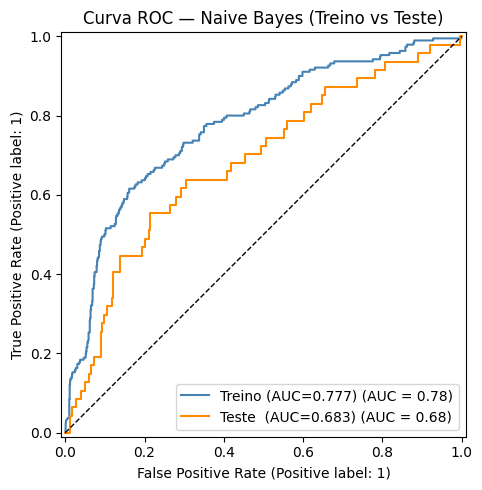

In [25]:
# 18. CURVAS ROC SOBREPOSTAS (NAIVE BAYES)

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino
RocCurveDisplay.from_predictions(
    resultados_treino_nb["y"], resultados_treino_nb["y_proba"],
    name=f"Treino (AUC={resultados_treino_nb['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste
RocCurveDisplay.from_predictions(
    resultados_teste_nb["y"], resultados_teste_nb["y_proba"],
    name=f"Teste  (AUC={resultados_teste_nb['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — Naive Bayes (Treino vs Teste)")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste_nb.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# 19. GERAR PROBABILIDADES DE SAÍDA (dataset completo - NAIVE BAYES)

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Adicionei errors='ignore' para evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_nb para não sobrescrever o teu trabalho da Regressão Logística
df_risco_nb = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do Naive Bayes
df_risco_nb["prob_saida"] = pipeline_nb.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_nb)} colaboradores (Naive Bayes).")
print(df_risco_nb["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (Naive Bayes).
count    1470.0000
mean        0.3936
std         0.4290
min         0.0000
25%         0.0000
50%         0.1272
75%         0.9141
90%         0.9984
max         1.0000
Name: prob_saida, dtype: float64


In [27]:
# 20. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (NAIVE BAYES)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

# Aplicar a função ao DataFrame do Naive Bayes
df_risco_nb["nivel_risco"] = df_risco_nb["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem_nb    = df_risco_nb["nivel_risco"].value_counts()
percentagem_nb = df_risco_nb["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (NAIVE BAYES) =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n   = contagem_nb.get(cat, 0)
    pct = percentagem_nb.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (NAIVE BAYES) =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo           811        55.2%
Médio            67         4.6%
Alto             82         5.6%
Crítico         510        34.7%


In [28]:
# 21. ANÁLISE POR CATEGORIA DE RISCO (NAIVE BAYES)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cols_analise = ["prob_saida", "Attrition_bin"]

# Adicionar variáveis de negócio para caracterizar cada nível de risco
for col in [
    "Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
    "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"
]:
    if col in df_risco_nb.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (NAIVE BAYES) =====")

perfil_nb = (
    df_risco_nb
    .groupby("nivel_risco")[cols_analise]
    .mean()
    .reindex(ORDEM)
    .round(3)
)

display(perfil_nb)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (NAIVE BAYES) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.029,0.072,39.624,8597.938,2.580,14.649,0.249,2.243,9.238
Médio,0.403,0.090,38.164,4159.910,1.507,10.134,0.254,2.149,6.701
Alto,0.606,0.134,34.134,4551.841,1.573,7.841,0.280,2.159,5.402
Crítico,0.939,0.318,32.916,3792.973,1.396,6.625,0.341,2.045,3.761


In [29]:
# 22. TOP 20 COLABORADORES COM MAIOR RISCO (NAIVE BAYES)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_nb.columns:
        cols_top.append(col)

top20_nb = df_risco_nb.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (NAIVE BAYES) =====")
display(top20_nb)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (NAIVE BAYES) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,1.0,Crítico,1,24,1555,1,0
1,1.0,Crítico,0,36,3886,2,0
2,1.0,Crítico,1,27,2863,1,0
3,1.0,Crítico,0,31,6410,2,0
4,1.0,Crítico,1,31,2956,1,0
5,1.0,Crítico,1,29,2335,1,1
6,1.0,Crítico,1,37,2073,1,1
7,1.0,Crítico,1,30,2180,1,0
8,1.0,Crítico,0,25,2187,1,0
9,1.0,Crítico,0,38,6077,2,0


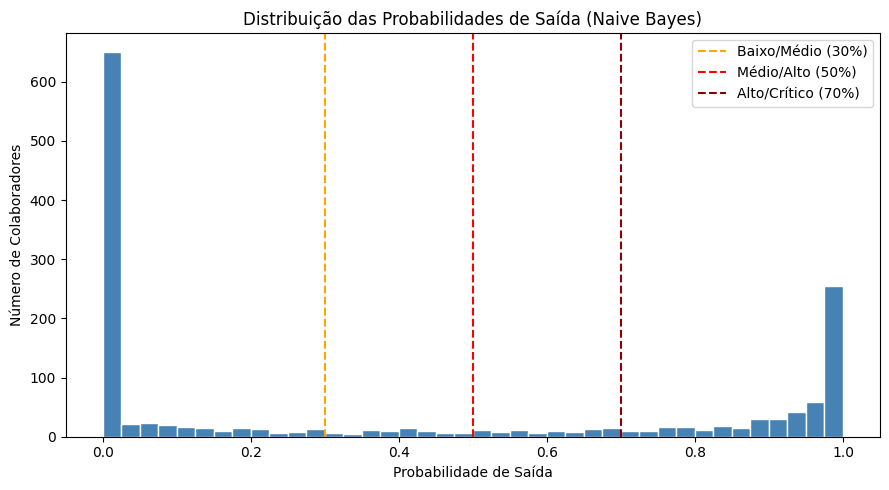

In [30]:
# 23. VISUALIZAÇÕES DO ÍNDICE DE RISCO (NAIVE BAYES)

# 23.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_risco_nb["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Novos thresholds corretos
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Baixo/Médio (30%)")
ax.axvline(0.50, color="red", linestyle="--", linewidth=1.5, label="Médio/Alto (50%)")
ax.axvline(0.70, color="darkred", linestyle="--", linewidth=1.5, label="Alto/Crítico (70%)")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (Naive Bayes)")

ax.legend()

plt.tight_layout()
plt.savefig("distribuicao_probabilidades_nb.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

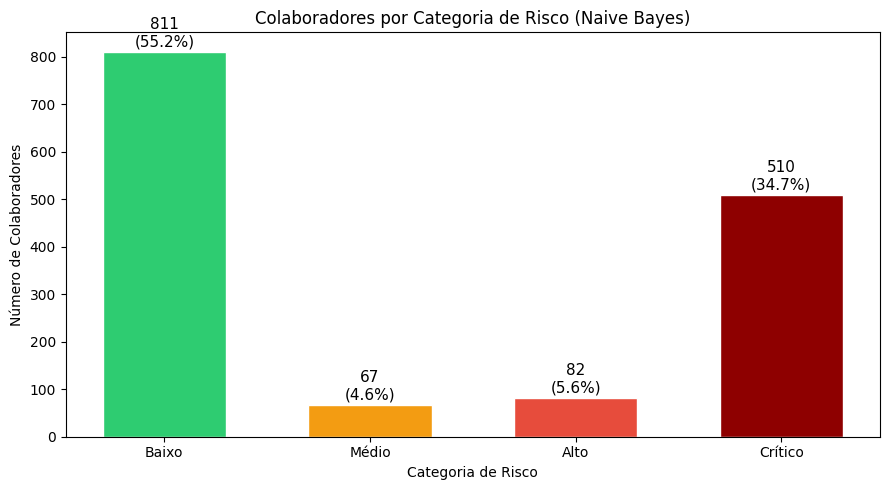

In [31]:
# 23.2 Contagem por categoria (NAIVE BAYES)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = {
    "Baixo": "#2ecc71",
    "Médio": "#f39c12",
    "Alto": "#e74c3c",
    "Crítico": "#8e0000"
}

fig, ax = plt.subplots(figsize=(9, 5))

vals = [contagem_nb.get(c, 0) for c in ORDEM]
bars = ax.bar(
    ORDEM,
    vals,
    color=[cores[c] for c in ORDEM],
    edgecolor="white",
    width=0.6
)

for bar, cat in zip(bars, ORDEM):
    n = contagem_nb.get(cat, 0)
    pct = percentagem_nb.get(cat, 0.0)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (Naive Bayes)")

plt.tight_layout()
plt.savefig("categorias_risco_nb.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

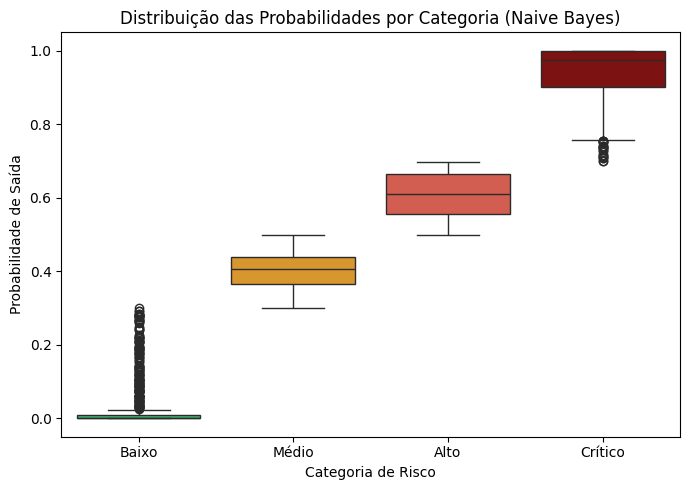

In [32]:
# 23.3 Boxplot por categoria (NAIVE BAYES)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = ["#2ecc71", "#f39c12", "#e74c3c", "#8e0000"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_risco_nb,
    x="nivel_risco",
    y="prob_saida",
    order=ORDEM,
    palette=cores,
    ax=ax
)

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (Naive Bayes)")

plt.tight_layout()
plt.savefig("boxplot_risco_nb.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [33]:
# 24. RESUMO FINAL (NAIVE BAYES)

print("=" * 55)
print("RESUMO — Naive Bayes")
print("=" * 55)

print(f"  Modelo:         Naive Bayes (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco_nb)}")

print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")

for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"  {nome:<12}  {resultados_treino_nb[metrica]:>8.4f}  {resultados_teste_nb[metrica]:>8.4f}")

print("\n  Distribuição das categorias de risco:")

print(f"  Baixo:    prob < 30%        -> {contagem_nb.get('Baixo', 0)} colaboradores")
print(f"  Médio:    30% ≤ prob < 50%  -> {contagem_nb.get('Médio', 0)} colaboradores")
print(f"  Alto:     50% ≤ prob < 70%  -> {contagem_nb.get('Alto', 0)} colaboradores")
print(f"  Crítico:  prob ≥ 70%        -> {contagem_nb.get('Crítico', 0)} colaboradores")

print("=" * 55)

RESUMO — Naive Bayes
  Modelo:         Naive Bayes (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.6769    0.6497
  Precision       0.3004    0.2586
  Recall          0.7526    0.6383
  F1-Score        0.4294    0.3681
  AUC-ROC         0.7768    0.6831

  Distribuição das categorias de risco:
  Baixo:    prob < 30%        -> 811 colaboradores
  Médio:    30% ≤ prob < 50%  -> 67 colaboradores
  Alto:     50% ≤ prob < 70%  -> 82 colaboradores
  Crítico:  prob ≥ 70%        -> 510 colaboradores


## 2. Candidato  - LDA (Linear Discriminant Analysis)

In [34]:
# 25. TREINO — LDA (LINEAR DISCRIMINANT ANALYSIS)
pipeline_lda = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

pipeline_lda.fit(X_train, y_train)
print("Modelo LDA treinado.")

Modelo LDA treinado.


In [35]:
# 26. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (LDA)

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [36]:
# 26.1 TREINO
resultados_treino_lda = avaliar_modelo(pipeline_lda, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.6454
  Precision: 0.8211
  Recall:    0.5316
  AUC-ROC:   0.8735

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       986
        Saiu       0.82      0.53      0.65       190

    accuracy                           0.91      1176
   macro avg       0.87      0.75      0.80      1176
weighted avg       0.90      0.91      0.90      1176



In [37]:
# 26.2 TESTE 
resultados_teste_lda  = avaliar_modelo(pipeline_lda, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.4167
  Precision: 0.6000
  Recall:    0.3191
  AUC-ROC:   0.8099

              precision    recall  f1-score   support

  Permaneceu       0.88      0.96      0.92       247
        Saiu       0.60      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.74      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294



In [38]:
# 27. COMPARAÇÃO TREINO vs TESTE (LDA)

print("===== COMPARAÇÃO TREINO vs TESTE (LDA) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_lda[metrica]
    val_teste  = resultados_teste_lda[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_lda = resultados_treino_lda["f1"] - resultados_teste_lda["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_lda > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE (LDA) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        0.9056    0.8571     +0.0485
  PRECISION       0.8211    0.6000     +0.2211
  RECALL          0.5316    0.3191     +0.2124
  F1              0.6454    0.4167     +0.2287
  AUC             0.8735    0.8099     +0.0636

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


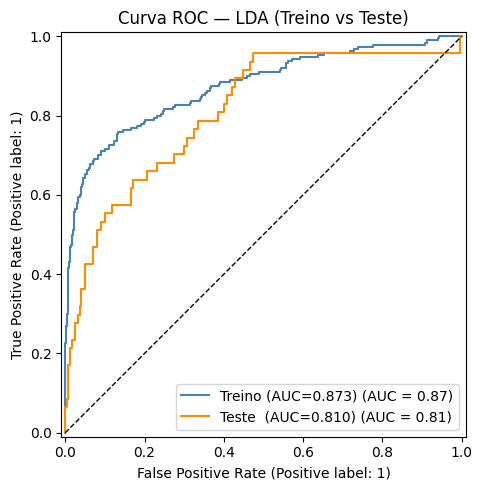

In [39]:
# 28. CURVAS ROC SOBREPOSTAS (LDA)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino
RocCurveDisplay.from_predictions(
    resultados_treino_lda["y"], resultados_treino_lda["y_proba"],
    name=f"Treino (AUC={resultados_treino_lda['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste
RocCurveDisplay.from_predictions(
    resultados_teste_lda["y"], resultados_teste_lda["y_proba"],
    name=f"Teste  (AUC={resultados_teste_lda['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — LDA (Treino vs Teste)")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste_lda.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
# 29. GERAR PROBABILIDADES DE SAÍDA (dataset completo - LDA)

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_lda para não sobrescrever o teu trabalho anterior
df_risco_lda = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do LDA
df_risco_lda["prob_saida"] = pipeline_lda.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_lda)} colaboradores (LDA).")
print(df_risco_lda["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (LDA).
count    1470.0000
mean        0.1567
std         0.2227
min         0.0000
25%         0.0157
50%         0.0586
75%         0.1902
90%         0.5010
max         0.9964
Name: prob_saida, dtype: float64


In [41]:
# 30. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (LDA)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

# Aplicar a função ao DataFrame do LDA
df_risco_lda["nivel_risco"] = df_risco_lda["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem_lda    = df_risco_lda["nivel_risco"].value_counts()
percentagem_lda = df_risco_lda["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (LDA) =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n   = contagem_lda.get(cat, 0)
    pct = percentagem_lda.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (LDA) =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo          1214        82.6%
Médio           108         7.3%
Alto             75         5.1%
Crítico          73         5.0%


In [42]:
# 31. ANÁLISE POR CATEGORIA DE RISCO (LDA)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cols_analise = ["prob_saida", "Attrition_bin"]

# Adicionar variáveis de negócio para caracterizar cada nível de risco
for col in [
    "Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
    "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"
]:
    if col in df_risco_lda.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (LDA) =====")

perfil_lda = (
    df_risco_lda
    .groupby("nivel_risco")[cols_analise]
    .mean()
    .reindex(ORDEM)
    .round(3)
)

display(perfil_lda)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (LDA) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.067,0.066,38.002,7008.591,2.186,12.188,0.220,2.212,7.638
Médio,0.389,0.380,33.259,4569.037,1.611,8.120,0.491,2.019,5.019
Alto,0.585,0.680,32.067,4179.973,1.507,7.533,0.667,1.960,4.293
Crítico,0.859,0.890,29.411,3341.452,1.274,4.699,0.630,1.822,2.260


In [43]:
# 32. TOP 20 COLABORADORES COM MAIOR RISCO (LDA)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_lda.columns:
        cols_top.append(col)

top20_lda = df_risco_lda.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (LDA) =====")
display(top20_lda)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (LDA) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.996399,Crítico,1,25,1118,1,1
1,0.994332,Crítico,1,26,2340,1,1
2,0.991633,Crítico,1,18,1878,1,1
3,0.987326,Crítico,1,21,2174,1,1
4,0.983142,Crítico,1,24,3172,1,1
5,0.981588,Crítico,1,19,1675,1,1
6,0.975440,Crítico,1,19,2121,1,1
7,0.975315,Crítico,1,18,1569,1,1
8,0.975195,Crítico,1,32,2795,1,1
9,0.974293,Crítico,1,19,2325,1,0


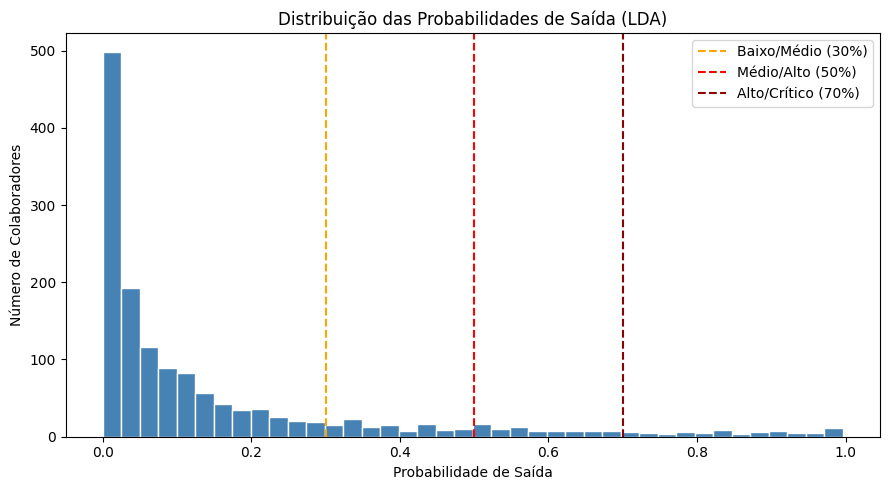

In [44]:
# 33. VISUALIZAÇÕES DO ÍNDICE DE RISCO (LDA)

# 33.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_risco_lda["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Thresholds atualizados
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Baixo/Médio (30%)")
ax.axvline(0.50, color="red", linestyle="--", linewidth=1.5, label="Médio/Alto (50%)")
ax.axvline(0.70, color="darkred", linestyle="--", linewidth=1.5, label="Alto/Crítico (70%)")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (LDA)")

ax.legend()

plt.tight_layout()
plt.savefig("distribuicao_probabilidades_lda.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

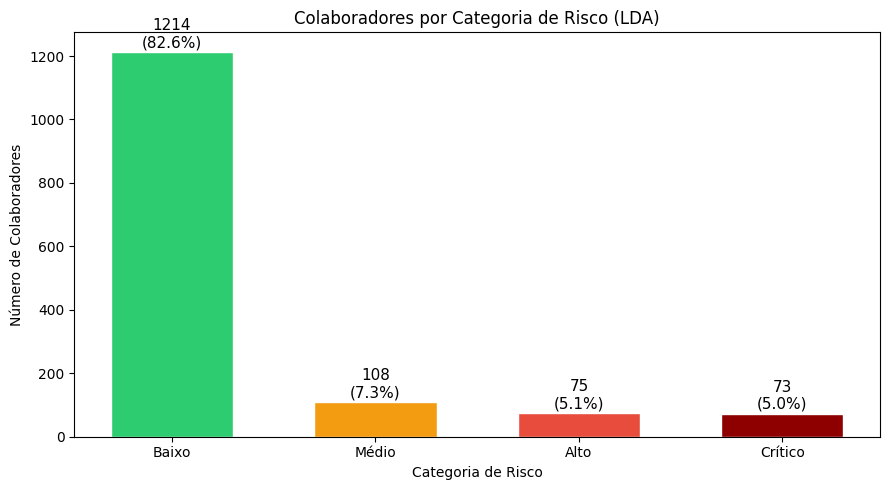

In [45]:
# 33.2 Contagem por categoria (LDA)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = {
    "Baixo": "#2ecc71",
    "Médio": "#f39c12",
    "Alto": "#e74c3c",
    "Crítico": "#8e0000"
}

fig, ax = plt.subplots(figsize=(9, 5))

vals = [contagem_lda.get(c, 0) for c in ORDEM]

bars = ax.bar(
    ORDEM,
    vals,
    color=[cores[c] for c in ORDEM],
    edgecolor="white",
    width=0.6
)

for bar, cat in zip(bars, ORDEM):
    n   = contagem_lda.get(cat, 0)
    pct = percentagem_lda.get(cat, 0.0)
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (LDA)")

plt.tight_layout()
plt.savefig("categorias_risco_lda.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

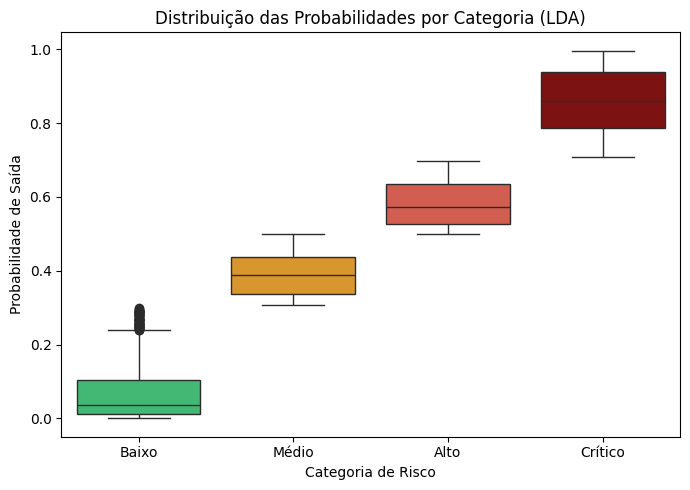

In [46]:
# 33.3 Boxplot por categoria (LDA)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = ["#2ecc71", "#f39c12", "#e74c3c", "#8e0000"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_risco_lda,
    x="nivel_risco",
    y="prob_saida",
    order=ORDEM,
    palette=cores,
    ax=ax
)

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (LDA)")

plt.tight_layout()
plt.savefig("boxplot_risco_lda.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [47]:
# 34. RESUMO FINAL (LDA)

print("=" * 55)
print("RESUMO — LDA")
print("=" * 55)

print(f"  Modelo:         LDA (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco_lda)}")

print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")

for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"  {nome:<12}  {resultados_treino_lda[metrica]:>8.4f}  {resultados_teste_lda[metrica]:>8.4f}")

print("\n  Distribuição das categorias de risco:")

print(f"  Baixo:    prob < 30%        -> {contagem_lda.get('Baixo', 0)} colaboradores")
print(f"  Médio:    30% ≤ prob < 50%  -> {contagem_lda.get('Médio', 0)} colaboradores")
print(f"  Alto:     50% ≤ prob < 70%  -> {contagem_lda.get('Alto', 0)} colaboradores")
print(f"  Crítico:  prob ≥ 70%        -> {contagem_lda.get('Crítico', 0)} colaboradores")

print("=" * 55)

RESUMO — LDA
  Modelo:         LDA (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.9056    0.8571
  Precision       0.8211    0.6000
  Recall          0.5316    0.3191
  F1-Score        0.6454    0.4167
  AUC-ROC         0.8735    0.8099

  Distribuição das categorias de risco:
  Baixo:    prob < 30%        -> 1214 colaboradores
  Médio:    30% ≤ prob < 50%  -> 108 colaboradores
  Alto:     50% ≤ prob < 70%  -> 75 colaboradores
  Crítico:  prob ≥ 70%        -> 73 colaboradores


## 3. Candidato  - KNN (K-NEAREST NEIGHBORS)
Modelo KNN com StandardScaler e classificação de risco.

In [48]:
# 35. TREINO — KNN (K-NEAREST NEIGHBORS)
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()) 
])

pipeline_knn.fit(X_train, y_train)
print("Modelo KNN treinado.")

Modelo KNN treinado.


In [49]:
# 36. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (KNN)
def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [50]:
# 36.1 TREINO
resultados_treino_knn = avaliar_modelo(pipeline_knn, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.4223
  Precision: 0.8689
  Recall:    0.2789
  AUC-ROC:   0.9163

              precision    recall  f1-score   support

  Permaneceu       0.88      0.99      0.93       986
        Saiu       0.87      0.28      0.42       190

    accuracy                           0.88      1176
   macro avg       0.87      0.64      0.68      1176
weighted avg       0.88      0.88      0.85      1176



In [51]:
# 36.2 TESTE
resultados_teste_knn  = avaliar_modelo(pipeline_knn, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.1724
  Precision: 0.4545
  Recall:    0.1064
  AUC-ROC:   0.6464

              precision    recall  f1-score   support

  Permaneceu       0.85      0.98      0.91       247
        Saiu       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



In [52]:
# 37. COMPARAÇÃO TREINO vs TESTE (KNN)

print("===== COMPARAÇÃO TREINO vs TESTE (KNN) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_knn[metrica]
    val_teste  = resultados_teste_knn[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_knn = resultados_treino_knn["f1"] - resultados_teste_knn["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_knn > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE (KNN) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        0.8767    0.8367     +0.0400
  PRECISION       0.8689    0.4545     +0.4143
  RECALL          0.2789    0.1064     +0.1726
  F1              0.4223    0.1724     +0.2499
  AUC             0.9163    0.6464     +0.2699

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


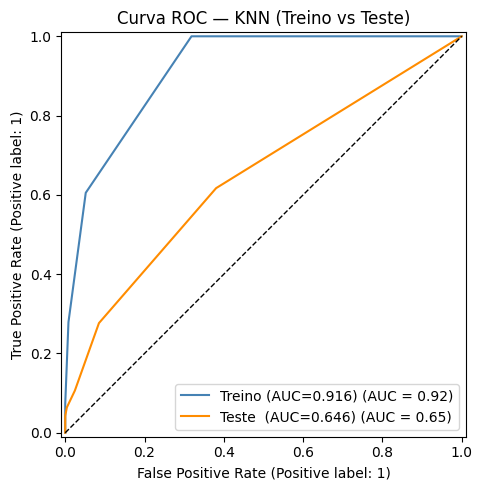

In [53]:
# 38. CURVAS ROC SOBREPOSTAS (KNN)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino
RocCurveDisplay.from_predictions(
    resultados_treino_knn["y"], resultados_treino_knn["y_proba"],
    name=f"Treino (AUC={resultados_treino_knn['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste
RocCurveDisplay.from_predictions(
    resultados_teste_knn["y"], resultados_teste_knn["y_proba"],
    name=f"Teste  (AUC={resultados_teste_knn['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — KNN (Treino vs Teste)")
plt.tight_layout()
plt.savefig("roc_treino_vs_teste_knn.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
# 39. GERAR PROBABILIDADES DE SAÍDA (dataset completo - KNN)
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_knn para não sobrescrever o teu trabalho anterior
df_risco_knn = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do KNN
df_risco_knn["prob_saida"] = pipeline_knn.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_knn)} colaboradores (KNN).")
print(df_risco_knn["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (KNN).
count    1470.0000
mean        0.1259
std         0.1810
min         0.0000
25%         0.0000
50%         0.0000
75%         0.2000
90%         0.4000
max         1.0000
Name: prob_saida, dtype: float64


In [55]:
# 40. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (KNN)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

# Aplicar a função ao DataFrame do KNN
df_risco_knn["nivel_risco"] = df_risco_knn["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem_knn    = df_risco_knn["nivel_risco"].value_counts()
percentagem_knn = df_risco_knn["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (KNN) =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n   = contagem_knn.get(cat, 0)
    pct = percentagem_knn.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (KNN) =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo          1270        86.4%
Médio           128         8.7%
Alto             54         3.7%
Crítico          18         1.2%


In [56]:
# 41. ANÁLISE POR CATEGORIA DE RISCO (KNN)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cols_analise = ["prob_saida", "Attrition_bin"]

# Adicionar variáveis de negócio para caracterizar cada nível de risco
for col in [
    "Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
    "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"
]:
    if col in df_risco_knn.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (KNN) =====")

perfil_knn = (
    df_risco_knn
    .groupby("nivel_risco")[cols_analise]
    .mean()
    .reindex(ORDEM)
    .round(3)
)

display(perfil_knn)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (KNN) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.067,0.086,37.654,6870.549,2.157,11.927,0.255,2.195,7.465
Médio,0.400,0.547,33.242,4501.734,1.539,7.984,0.430,2.000,4.727
Alto,0.600,0.759,31.907,3870.463,1.407,6.667,0.463,1.907,3.167
Crítico,0.889,0.944,26.667,2693.611,1.167,2.889,0.667,2.000,2.556


In [57]:
# 42. TOP 20 COLABORADORES COM MAIOR RISCO (KNN)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_knn.columns:
        cols_top.append(col)

top20_knn = df_risco_knn.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (KNN) =====")
display(top20_knn)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (KNN) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,1.0,Crítico,1,21,2174,1,1
1,1.0,Crítico,1,26,2340,1,1
2,1.0,Crítico,1,25,1118,1,1
3,1.0,Crítico,1,52,8446,3,1
4,1.0,Crítico,1,31,2302,1,1
5,1.0,Crítico,1,31,2785,1,0
6,1.0,Crítico,1,31,1359,1,0
7,1.0,Crítico,1,18,1569,1,1
8,0.8,Crítico,1,32,3919,1,1
9,0.8,Crítico,1,19,2325,1,0


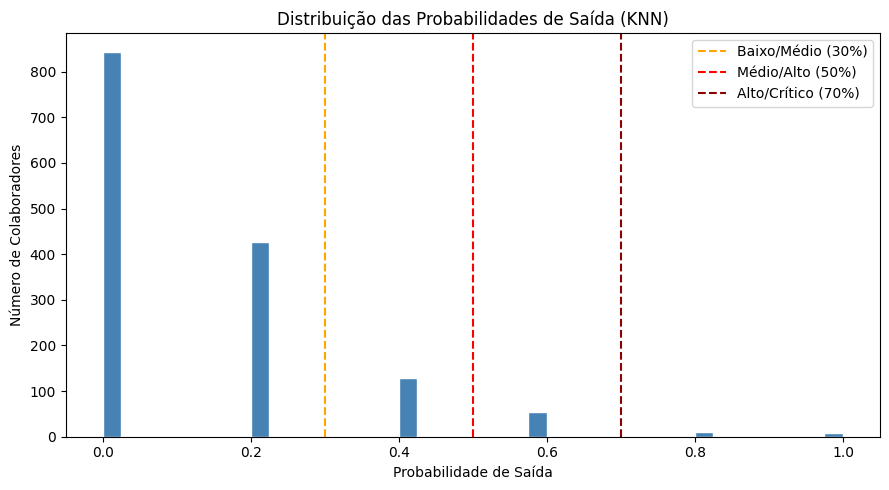

In [58]:
# 43. VISUALIZAÇÕES DO ÍNDICE DE RISCO (KNN)

import matplotlib.pyplot as plt

# 43.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_risco_knn["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Thresholds corretos
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Baixo/Médio (30%)")
ax.axvline(0.50, color="red", linestyle="--", linewidth=1.5, label="Médio/Alto (50%)")
ax.axvline(0.70, color="darkred", linestyle="--", linewidth=1.5, label="Alto/Crítico (70%)")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (KNN)")

ax.legend()

plt.tight_layout()
plt.savefig("distribuicao_probabilidades_knn.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

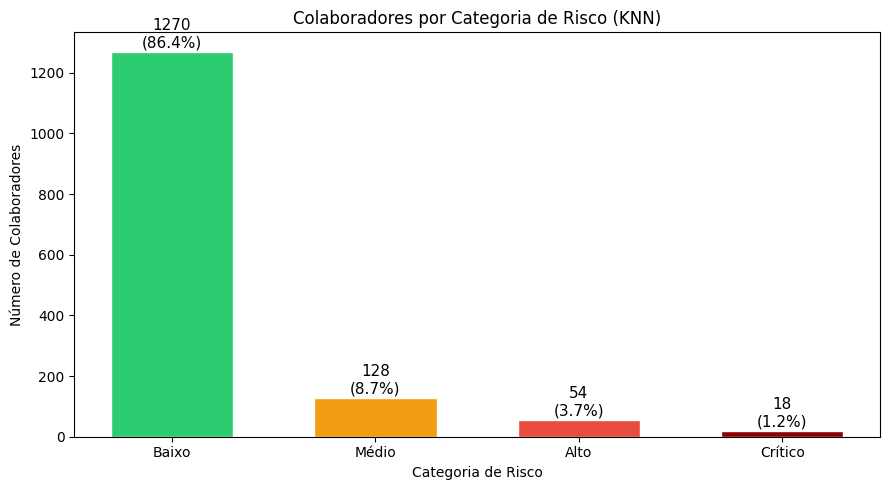

In [59]:
# 43.2 Contagem por categoria (KNN)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = {
    "Baixo": "#2ecc71",
    "Médio": "#f39c12",
    "Alto": "#e74c3c",
    "Crítico": "#8e0000"
}

fig, ax = plt.subplots(figsize=(9, 5))

# Valores das categorias
vals = [contagem_knn.get(c, 0) for c in ORDEM]

bars = ax.bar(
    ORDEM,
    vals,
    color=[cores[c] for c in ORDEM],
    edgecolor="white",
    width=0.6
)

# Labels (nº + %)
for bar, cat in zip(bars, ORDEM):
    n   = contagem_knn.get(cat, 0)
    pct = percentagem_knn.get(cat, 0.0)
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (KNN)")

plt.tight_layout()
plt.savefig("categorias_risco_knn.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

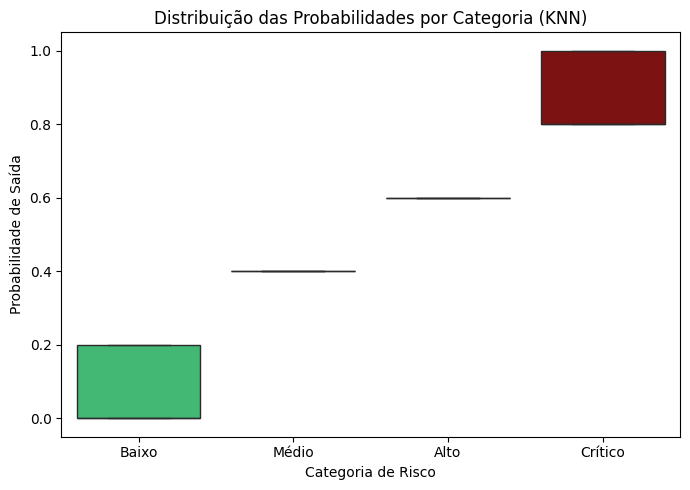

In [60]:
# 43.3 Boxplot por categoria (KNN)

import matplotlib.pyplot as plt
import seaborn as sns

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = ["#2ecc71", "#f39c12", "#e74c3c", "#8e0000"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_risco_knn,
    x="nivel_risco",
    y="prob_saida",
    order=ORDEM,
    palette=cores,
    ax=ax
)

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (KNN)")

plt.tight_layout()
plt.savefig("boxplot_risco_knn.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [61]:
# 44. RESUMO FINAL (KNN)

print("=" * 55)
print("RESUMO — KNN")
print("=" * 55)

print(f"  Modelo:         KNN (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco_knn)}")

print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")

for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"  {nome:<12}  {resultados_treino_knn[metrica]:>8.4f}  {resultados_teste_knn[metrica]:>8.4f}")

print("\n  Distribuição das categorias de risco:")

print(f"  Baixo:    prob < 30%        -> {contagem_knn.get('Baixo', 0)} colaboradores")
print(f"  Médio:    30% ≤ prob < 50%  -> {contagem_knn.get('Médio', 0)} colaboradores")
print(f"  Alto:     50% ≤ prob < 70%  -> {contagem_knn.get('Alto', 0)} colaboradores")
print(f"  Crítico:  prob ≥ 70%        -> {contagem_knn.get('Crítico', 0)} colaboradores")

print("=" * 55)

RESUMO — KNN
  Modelo:         KNN (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.8767    0.8367
  Precision       0.8689    0.4545
  Recall          0.2789    0.1064
  F1-Score        0.4223    0.1724
  AUC-ROC         0.9163    0.6464

  Distribuição das categorias de risco:
  Baixo:    prob < 30%        -> 1270 colaboradores
  Médio:    30% ≤ prob < 50%  -> 128 colaboradores
  Alto:     50% ≤ prob < 70%  -> 54 colaboradores
  Crítico:  prob ≥ 70%        -> 18 colaboradores


## 4. Candidato - Extra Trees 


In [62]:
# 45. TREINO — EXTRA TREES
pipeline_et = Pipeline([
    ("scaler", StandardScaler()),
    ("et", ExtraTreesClassifier(random_state=42)) 
])

pipeline_et.fit(X_train, y_train)
print("Modelo Extra Trees treinado.")

Modelo Extra Trees treinado.


In [63]:
# 46. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (EXTRA TREES)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [64]:
# 46.1 TREINO
resultados_treino_et = avaliar_modelo(pipeline_et, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [65]:
# 46.2 TESTE
resultados_teste_et  = avaliar_modelo(pipeline_et, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.2143
  Precision: 0.6667
  Recall:    0.1277
  AUC-ROC:   0.8099

              precision    recall  f1-score   support

  Permaneceu       0.86      0.99      0.92       247
        Saiu       0.67      0.13      0.21        47

    accuracy                           0.85       294
   macro avg       0.76      0.56      0.57       294
weighted avg       0.83      0.85      0.80       294



In [66]:
# 47. COMPARAÇÃO TREINO vs TESTE (EXTRA TREES)

print("===== COMPARAÇÃO TREINO vs TESTE (EXTRA TREES) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_et[metrica]
    val_teste  = resultados_teste_et[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_et = resultados_treino_et["f1"] - resultados_teste_et["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_et > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting.")

===== COMPARAÇÃO TREINO vs TESTE (EXTRA TREES) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        1.0000    0.8503     +0.1497
  PRECISION       1.0000    0.6667     +0.3333
  RECALL          1.0000    0.1277     +0.8723
  F1              1.0000    0.2143     +0.7857
  AUC             1.0000    0.8099     +0.1901

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


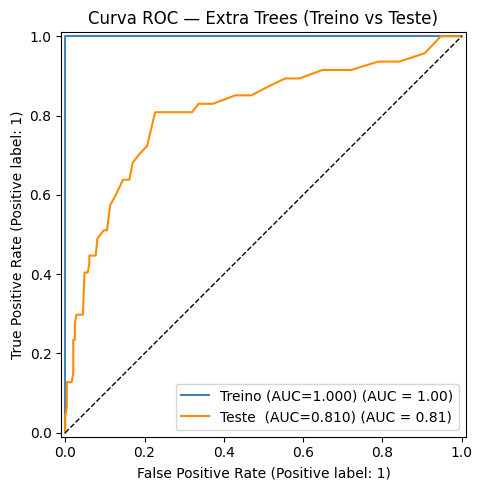

In [67]:
# 48. CURVAS ROC SOBREPOSTAS (EXTRA TREES)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino - Usando os resultados do Extra Trees
RocCurveDisplay.from_predictions(
    resultados_treino_et["y"], resultados_treino_et["y_proba"],
    name=f"Treino (AUC={resultados_treino_et['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste - Usando os resultados do Extra Trees
RocCurveDisplay.from_predictions(
    resultados_teste_et["y"], resultados_teste_et["y_proba"],
    name=f"Teste  (AUC={resultados_teste_et['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — Extra Trees (Treino vs Teste)")
plt.tight_layout()
# Salvando com um nome de arquivo diferente
plt.savefig("roc_treino_vs_teste_et.png", dpi=150, bbox_inches="tight")
plt.show()

In [68]:
# 49. GERAR PROBABILIDADES DE SAÍDA (dataset completo - EXTRA TREES)
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_et para não sobrescrever o teu trabalho anterior
df_risco_et = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do Extra Trees
df_risco_et["prob_saida"] = pipeline_et.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_et)} colaboradores (Extra Trees).")
print(df_risco_et["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (Extra Trees).
count    1470.0000
mean        0.1623
std         0.3355
min         0.0000
25%         0.0000
50%         0.0000
75%         0.1000
90%         1.0000
max         1.0000
Name: prob_saida, dtype: float64


In [69]:
# 50. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (EXTRA TREES)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

# Aplicar a função ao DataFrame do Extra Trees
df_risco_et["nivel_risco"] = df_risco_et["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem_et    = df_risco_et["nivel_risco"].value_counts()
percentagem_et = df_risco_et["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (EXTRA TREES) =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n   = contagem_et.get(cat, 0)
    pct = percentagem_et.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (EXTRA TREES) =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo          1240        84.4%
Médio            30         2.0%
Alto              6         0.4%
Crítico         194        13.2%


In [70]:
# 51. ANÁLISE POR CATEGORIA DE RISCO (EXTRA TREES)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cols_analise = ["prob_saida", "Attrition_bin"]

# Adicionar variáveis de negócio para caracterizar cada nível de risco
for col in [
    "Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
    "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"
]:
    if col in df_risco_et.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (EXTRA TREES) =====")

perfil_et = (
    df_risco_et
    .groupby("nivel_risco")[cols_analise]
    .mean()
    .reindex(ORDEM)
    .round(3)
)

display(perfil_et)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (EXTRA TREES) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.024,0.021,37.689,6860.201,2.152,11.979,0.234,2.201,7.472
Médio,0.394,0.500,32.567,3698.200,1.333,4.967,0.700,2.167,2.933
Alto,0.555,0.500,31.667,2460.667,1.000,7.000,0.833,1.833,2.167
Crítico,0.996,0.995,32.871,4778.093,1.649,7.918,0.515,1.948,4.825


In [71]:
# 52. TOP 20 COLABORADORES COM MAIOR RISCO (EXTRA TREES)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_et.columns:
        cols_top.append(col)

top20_et = df_risco_et.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (EXTRA TREES) =====")
display(top20_et)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (EXTRA TREES) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,1.0,Crítico,1,41,5993,2,1
1,1.0,Crítico,1,28,2028,1,1
2,1.0,Crítico,1,36,3407,1,0
3,1.0,Crítico,1,32,3919,1,1
4,1.0,Crítico,1,39,2086,2,0
5,1.0,Crítico,1,24,2293,1,1
6,1.0,Crítico,1,26,2293,1,0
7,1.0,Crítico,1,48,5381,3,1
8,1.0,Crítico,1,28,3441,1,1
9,1.0,Crítico,1,46,9619,3,0


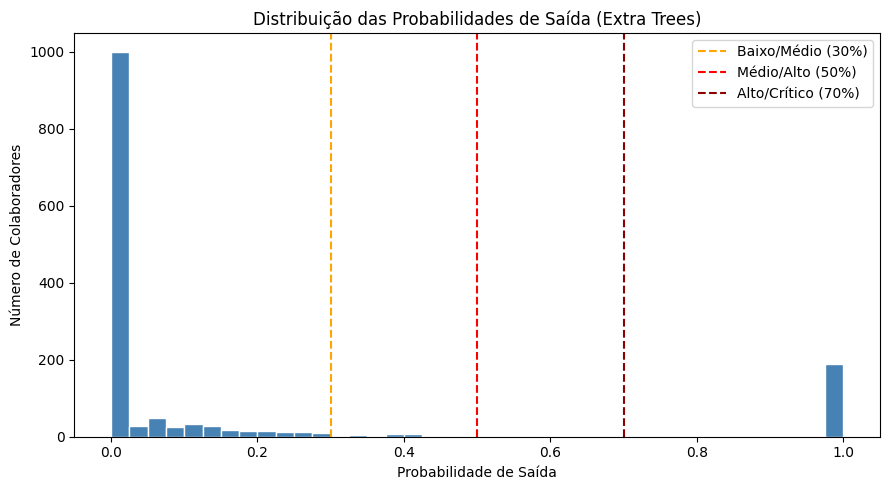

In [72]:
# 53. VISUALIZAÇÕES DO ÍNDICE DE RISCO (EXTRA TREES)

import matplotlib.pyplot as plt

# 53.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_risco_et["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Thresholds corretos
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Baixo/Médio (30%)")
ax.axvline(0.50, color="red", linestyle="--", linewidth=1.5, label="Médio/Alto (50%)")
ax.axvline(0.70, color="darkred", linestyle="--", linewidth=1.5, label="Alto/Crítico (70%)")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (Extra Trees)")

ax.legend()

plt.tight_layout()
plt.savefig("distribuicao_probabilidades_et.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

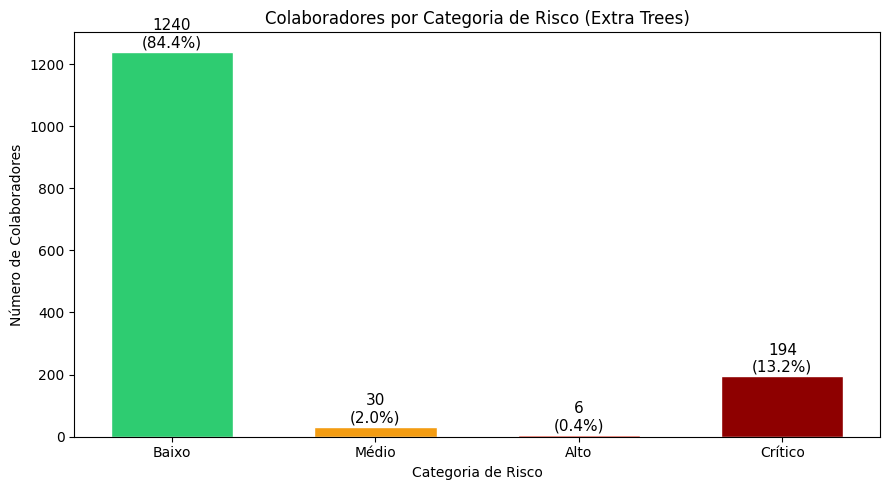

In [73]:
# 53.2 Contagem por categoria (EXTRA TREES)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = {
    "Baixo": "#2ecc71",
    "Médio": "#f39c12",
    "Alto": "#e74c3c",
    "Crítico": "#8e0000"
}

fig, ax = plt.subplots(figsize=(9, 5))

# Valores das categorias
vals = [contagem_et.get(c, 0) for c in ORDEM]

bars = ax.bar(
    ORDEM,
    vals,
    color=[cores[c] for c in ORDEM],
    edgecolor="white",
    width=0.6
)

# Labels (nº + %)
for bar, cat in zip(bars, ORDEM):
    n   = contagem_et.get(cat, 0)
    pct = percentagem_et.get(cat, 0.0)
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (Extra Trees)")

plt.tight_layout()
plt.savefig("categorias_risco_et.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

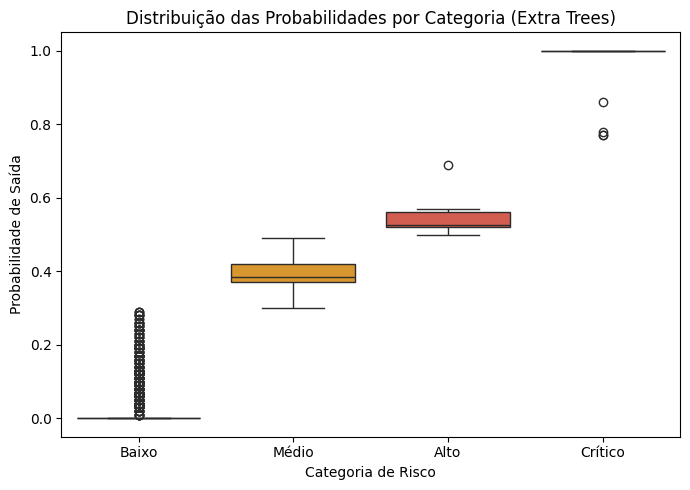

In [74]:
# 53.3 Boxplot por categoria (EXTRA TREES)

import matplotlib.pyplot as plt
import seaborn as sns

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = ["#2ecc71", "#f39c12", "#e74c3c", "#8e0000"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_risco_et,
    x="nivel_risco",
    y="prob_saida",
    order=ORDEM,
    palette=cores,
    ax=ax
)

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (Extra Trees)")

plt.tight_layout()
plt.savefig("boxplot_risco_et.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [75]:
# 54. RESUMO FINAL (EXTRA TREES)

print("=" * 55)
print("RESUMO — EXTRA TREES")
print("=" * 55)

print(f"  Modelo:         Extra Trees (parâmetros default)")
print(f"  Colaboradores:  {len(df_risco_et)}")

print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")

for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"  {nome:<12}  {resultados_treino_et[metrica]:>8.4f}  {resultados_teste_et[metrica]:>8.4f}")

print("\n  Distribuição das categorias de risco:")

print(f"  Baixo:    prob < 30%        -> {contagem_et.get('Baixo', 0)} colaboradores")
print(f"  Médio:    30% ≤ prob < 50%  -> {contagem_et.get('Médio', 0)} colaboradores")
print(f"  Alto:     50% ≤ prob < 70%  -> {contagem_et.get('Alto', 0)} colaboradores")
print(f"  Crítico:  prob ≥ 70%        -> {contagem_et.get('Crítico', 0)} colaboradores")

print("=" * 55)

RESUMO — EXTRA TREES
  Modelo:         Extra Trees (parâmetros default)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        1.0000    0.8503
  Precision       1.0000    0.6667
  Recall          1.0000    0.1277
  F1-Score        1.0000    0.2143
  AUC-ROC         1.0000    0.8099

  Distribuição das categorias de risco:
  Baixo:    prob < 30%        -> 1240 colaboradores
  Médio:    30% ≤ prob < 50%  -> 30 colaboradores
  Alto:     50% ≤ prob < 70%  -> 6 colaboradores
  Crítico:  prob ≥ 70%        -> 194 colaboradores


## 5. Candidato  - SVM (SUPPORT VECTOR MACHINE)
Modelo SVM com StandardScaler e classificação de risco.

In [76]:
# 55. TREINO — SUPPORT VECTOR MACHINE (SVM)
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42)) 
])

pipeline_svm.fit(X_train, y_train)
print("Modelo Support Vector Machine (SVM) treinado.")

Modelo Support Vector Machine (SVM) treinado.


In [77]:
# 56. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (SVM)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [78]:
# 56.1 TREINO
resultados_treino_svm = avaliar_modelo(pipeline_svm, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.6851
  Precision: 1.0000
  Recall:    0.5211
  AUC-ROC:   0.9654

              precision    recall  f1-score   support

  Permaneceu       0.92      1.00      0.96       986
        Saiu       1.00      0.52      0.69       190

    accuracy                           0.92      1176
   macro avg       0.96      0.76      0.82      1176
weighted avg       0.93      0.92      0.91      1176



In [79]:
# 56.2 TESTE
resultados_teste_svm  = avaliar_modelo(pipeline_svm, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.2712
  Precision: 0.6667
  Recall:    0.1702
  AUC-ROC:   0.8086

              precision    recall  f1-score   support

  Permaneceu       0.86      0.98      0.92       247
        Saiu       0.67      0.17      0.27        47

    accuracy                           0.85       294
   macro avg       0.76      0.58      0.59       294
weighted avg       0.83      0.85      0.82       294



In [80]:
# 57. COMPARAÇÃO TREINO vs TESTE (SVM)

print("===== COMPARAÇÃO TREINO vs TESTE (SVM) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário do SVM
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_svm[metrica]
    val_teste  = resultados_teste_svm[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_svm = resultados_treino_svm["f1"] - resultados_teste_svm["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_svm > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting (Modelo Estável).")

===== COMPARAÇÃO TREINO vs TESTE (SVM) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        0.9226    0.8537     +0.0689
  PRECISION       1.0000    0.6667     +0.3333
  RECALL          0.5211    0.1702     +0.3508
  F1              0.6851    0.2712     +0.4139
  AUC             0.9654    0.8086     +0.1568

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


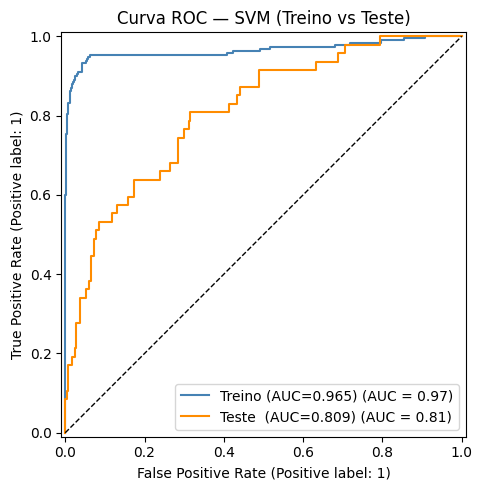

In [81]:
# 58. CURVAS ROC SOBREPOSTAS (SVM)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino - Usando os resultados do SVM
RocCurveDisplay.from_predictions(
    resultados_treino_svm["y"], resultados_treino_svm["y_proba"],
    name=f"Treino (AUC={resultados_treino_svm['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste - Usando os resultados do SVM
RocCurveDisplay.from_predictions(
    resultados_teste_svm["y"], resultados_teste_svm["y_proba"],
    name=f"Teste  (AUC={resultados_teste_svm['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — SVM (Treino vs Teste)")
plt.tight_layout()

# Salvando com o nome do modelo atual
plt.savefig("roc_treino_vs_teste_svm.png", dpi=150, bbox_inches="tight")
plt.show()

In [82]:
# 59. GERAR PROBABILIDADES DE SAÍDA (dataset completo - SVM)
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_svm para não sobrescrever o trabalho do Extra Trees ou KNN
df_risco_svm = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do SVM
df_risco_svm["prob_saida"] = pipeline_svm.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_svm)} colaboradores (SVM).")
print(df_risco_svm["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (SVM).
count    1470.0000
mean        0.1626
std         0.2354
min         0.0016
25%         0.0370
50%         0.0851
75%         0.1051
90%         0.5234
max         0.9926
Name: prob_saida, dtype: float64


In [83]:
# 60. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (SVM)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

# Aplicar a função ao DataFrame do SVM
df_risco_svm["nivel_risco"] = df_risco_svm["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem_svm    = df_risco_svm["nivel_risco"].value_counts()
percentagem_svm = df_risco_svm["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (SVM) =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n   = contagem_svm.get(cat, 0)
    pct = percentagem_svm.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (SVM) =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo          1256        85.4%
Médio            59         4.0%
Alto             47         3.2%
Crítico         108         7.3%


In [84]:
# 61. ANÁLISE POR CATEGORIA DE RISCO (SVM)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cols_analise = ["prob_saida", "Attrition_bin"]

# Adicionar variáveis de negócio para caracterizar cada nível de risco
for col in [
    "Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
    "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"
]:
    if col in df_risco_svm.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (SVM) =====")

perfil_svm = (
    df_risco_svm
    .groupby("nivel_risco")[cols_analise]
    .mean()
    .reindex(ORDEM)
    .round(3)
)

display(perfil_svm)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (SVM) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.074,0.044,37.834,6877.959,2.158,12.010,0.235,2.206,7.506
Médio,0.393,0.593,31.644,4126.356,1.492,6.966,0.508,2.017,4.169
Alto,0.595,0.915,34.809,6180.681,1.936,10.085,0.553,2.043,6.383
Crítico,0.875,0.963,30.139,3580.046,1.333,5.657,0.602,1.824,3.037


In [85]:
# 62. TOP 20 COLABORADORES COM MAIOR RISCO (SVM)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_svm.columns:
        cols_top.append(col)

# Usar o DataFrame do SVM para encontrar os 20 casos mais críticos
top20_svm = df_risco_svm.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (SVM) =====")
display(top20_svm)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (SVM) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.992620,Crítico,1,18,1878,1,1
1,0.991179,Crítico,1,31,1359,1,0
2,0.990970,Crítico,1,24,3172,1,1
3,0.990518,Crítico,1,26,2340,1,1
4,0.988481,Crítico,1,32,2795,1,1
5,0.983114,Crítico,1,25,1118,1,1
6,0.982749,Crítico,1,18,1569,1,1
7,0.981282,Crítico,1,21,2174,1,1
8,0.976864,Crítico,1,23,1790,1,0
9,0.976849,Crítico,1,32,3919,1,1


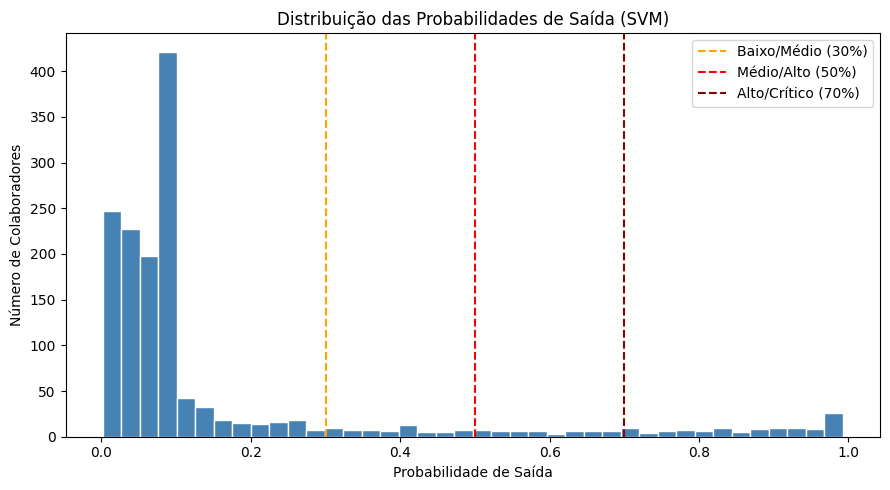

In [86]:
# 63. VISUALIZAÇÕES DO ÍNDICE DE RISCO (SVM)

import matplotlib.pyplot as plt

# 63.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_risco_svm["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Thresholds corretos
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Baixo/Médio (30%)")
ax.axvline(0.50, color="red", linestyle="--", linewidth=1.5, label="Médio/Alto (50%)")
ax.axvline(0.70, color="darkred", linestyle="--", linewidth=1.5, label="Alto/Crítico (70%)")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (SVM)")

ax.legend()

plt.tight_layout()
plt.savefig("distribuicao_probabilidades_svm.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

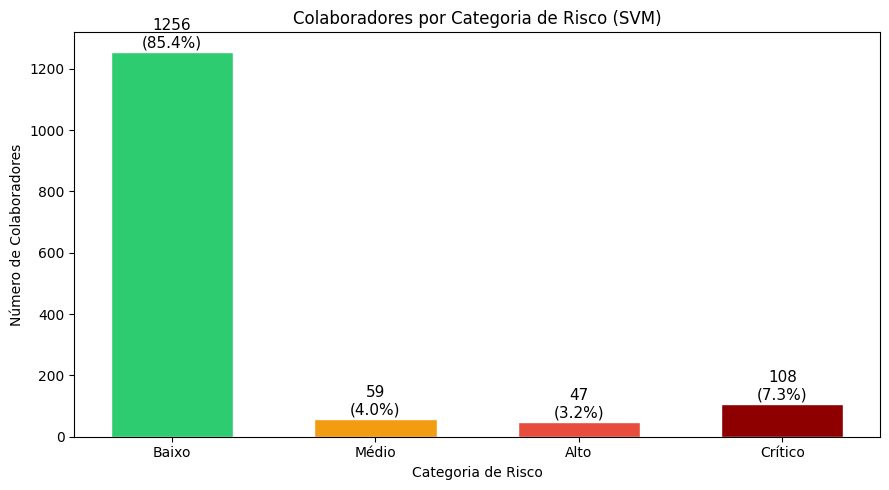

In [87]:
# 63.2 Contagem por categoria (SVM)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = {
    "Baixo": "#2ecc71",
    "Médio": "#f39c12",
    "Alto": "#e74c3c",
    "Crítico": "#8e0000"
}

fig, ax = plt.subplots(figsize=(9, 5))

# Valores das categorias
vals = [contagem_svm.get(c, 0) for c in ORDEM]

bars = ax.bar(
    ORDEM,
    vals,
    color=[cores[c] for c in ORDEM],
    edgecolor="white",
    width=0.6
)

# Labels (nº + %)
for bar, cat in zip(bars, ORDEM):
    n   = contagem_svm.get(cat, 0)
    pct = percentagem_svm.get(cat, 0.0)
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (SVM)")

plt.tight_layout()
plt.savefig("categorias_risco_svm.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

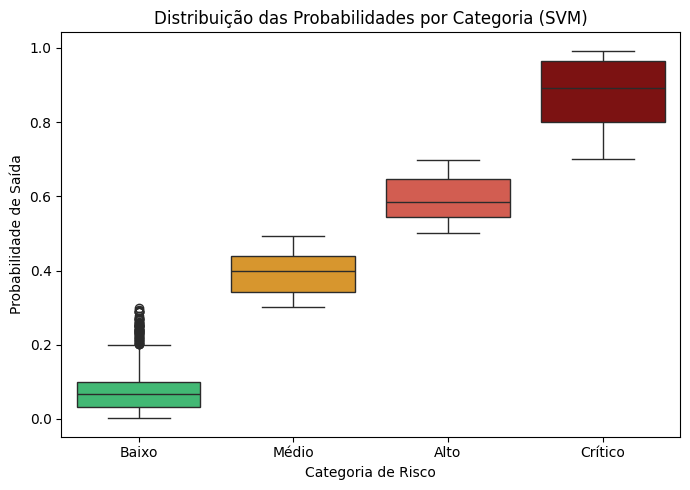

In [88]:
# 63.3 Boxplot por categoria (SVM)

import matplotlib.pyplot as plt
import seaborn as sns

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = ["#2ecc71", "#f39c12", "#e74c3c", "#8e0000"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_risco_svm,
    x="nivel_risco",
    y="prob_saida",
    order=ORDEM,
    palette=cores,
    ax=ax
)

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (SVM)")

plt.tight_layout()
plt.savefig("boxplot_risco_svm.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [89]:
# 64. RESUMO FINAL (SVM)

print("=" * 55)
print("RESUMO — SVM")
print("=" * 55)

print(f"  Modelo:         Support Vector Machine (SVC)")
print(f"  Colaboradores:  {len(df_risco_svm)}")

print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")

for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"  {nome:<12}  {resultados_treino_svm[metrica]:>8.4f}  {resultados_teste_svm[metrica]:>8.4f}")

print("\n  Distribuição das categorias de risco:")

print(f"  Baixo:    prob < 30%        -> {contagem_svm.get('Baixo', 0)} colaboradores")
print(f"  Médio:    30% ≤ prob < 50%  -> {contagem_svm.get('Médio', 0)} colaboradores")
print(f"  Alto:     50% ≤ prob < 70%  -> {contagem_svm.get('Alto', 0)} colaboradores")
print(f"  Crítico:  prob ≥ 70%        -> {contagem_svm.get('Crítico', 0)} colaboradores")

print("=" * 55)

RESUMO — SVM
  Modelo:         Support Vector Machine (SVC)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.9226    0.8537
  Precision       1.0000    0.6667
  Recall          0.5211    0.1702
  F1-Score        0.6851    0.2712
  AUC-ROC         0.9654    0.8086

  Distribuição das categorias de risco:
  Baixo:    prob < 30%        -> 1256 colaboradores
  Médio:    30% ≤ prob < 50%  -> 59 colaboradores
  Alto:     50% ≤ prob < 70%  -> 47 colaboradores
  Crítico:  prob ≥ 70%        -> 108 colaboradores


## 6. Candidato  - ADABOOST 

In [90]:
# 65. TREINO — ADABOOST
pipeline_ada = Pipeline([
    ("scaler", StandardScaler()),
    ("ada", AdaBoostClassifier(random_state=42, n_estimators=100)) 
])

pipeline_ada.fit(X_train, y_train)
print("Modelo AdaBoost treinado.")

Modelo AdaBoost treinado.


In [91]:
# 66. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (ADABOOST)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [92]:
# 66.1 TREINO
resultados_treino_ada = avaliar_modelo(pipeline_ada, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  0.6133
  Precision: 0.8364
  Recall:    0.4842
  AUC-ROC:   0.9145

              precision    recall  f1-score   support

  Permaneceu       0.91      0.98      0.94       986
        Saiu       0.84      0.48      0.61       190

    accuracy                           0.90      1176
   macro avg       0.87      0.73      0.78      1176
weighted avg       0.90      0.90      0.89      1176



In [93]:
# 66.2 TESTE 
resultados_teste_ada  = avaliar_modelo(pipeline_ada, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.3889
  Precision: 0.5600
  Recall:    0.2979
  AUC-ROC:   0.8022

              precision    recall  f1-score   support

  Permaneceu       0.88      0.96      0.91       247
        Saiu       0.56      0.30      0.39        47

    accuracy                           0.85       294
   macro avg       0.72      0.63      0.65       294
weighted avg       0.83      0.85      0.83       294



In [94]:
# 67. COMPARAÇÃO TREINO vs TESTE (ADABOOST)

print("===== COMPARAÇÃO TREINO vs TESTE (ADABOOST) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário do AdaBoost
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_ada[metrica]
    val_teste  = resultados_teste_ada[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_ada = resultados_treino_ada["f1"] - resultados_teste_ada["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_ada > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting (Modelo Estável).")

===== COMPARAÇÃO TREINO vs TESTE (ADABOOST) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        0.9014    0.8503     +0.0510
  PRECISION       0.8364    0.5600     +0.2764
  RECALL          0.4842    0.2979     +0.1863
  F1              0.6133    0.3889     +0.2244
  AUC             0.9145    0.8022     +0.1123

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


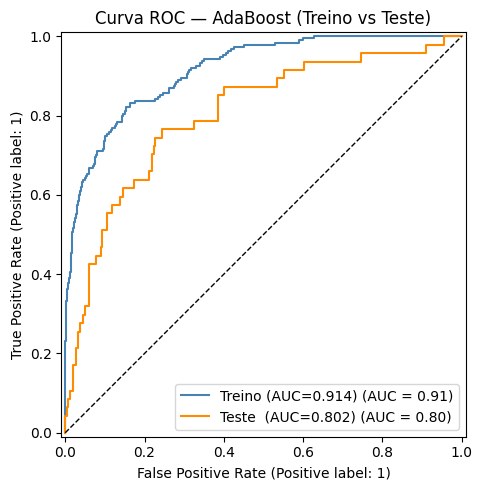

In [95]:
# 68. CURVAS ROC SOBREPOSTAS (ADABOOST)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino - Usando os resultados do AdaBoost
RocCurveDisplay.from_predictions(
    resultados_treino_ada["y"], resultados_treino_ada["y_proba"],
    name=f"Treino (AUC={resultados_treino_ada['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste - Usando os resultados do AdaBoost
RocCurveDisplay.from_predictions(
    resultados_teste_ada["y"], resultados_teste_ada["y_proba"],
    name=f"Teste  (AUC={resultados_teste_ada['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — AdaBoost (Treino vs Teste)")
plt.tight_layout()

# Salvando com o nome do modelo atual
plt.savefig("roc_treino_vs_teste_ada.png", dpi=150, bbox_inches="tight")
plt.show()

In [96]:
# 69. GERAR PROBABILIDADES DE SAÍDA (dataset completo - ADABOOST)
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_ada para não sobrescrever o trabalho do SVM, Extra Trees ou KNN
df_risco_ada = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do AdaBoost
df_risco_ada["prob_saida"] = pipeline_ada.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_ada)} colaboradores (AdaBoost).")
print(df_risco_ada["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (AdaBoost).
count    1470.0000
mean        0.4247
std         0.0561
min         0.2698
25%         0.3870
50%         0.4221
75%         0.4574
90%         0.4957
max         0.6542
Name: prob_saida, dtype: float64


In [97]:
# 70. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (ADABOOST)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

# Aplicar a função ao DataFrame do AdaBoost
df_risco_ada["nivel_risco"] = df_risco_ada["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem_ada    = df_risco_ada["nivel_risco"].value_counts()
percentagem_ada = df_risco_ada["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (ADABOOST) =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n   = contagem_ada.get(cat, 0)
    pct = percentagem_ada.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (ADABOOST) =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo             8         0.5%
Médio          1327        90.3%
Alto            135         9.2%
Crítico           0         0.0%


In [98]:
# 71. ANÁLISE POR CATEGORIA DE RISCO (ADABOOST)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cols_analise = ["prob_saida", "Attrition_bin"]

# Adicionar variáveis de negócio para caracterizar cada nível de risco
for col in [
    "Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
    "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"
]:
    if col in df_risco_ada.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (ADABOOST) =====")

perfil_ada = (
    df_risco_ada
    .groupby("nivel_risco")[cols_analise]
    .mean()
    .reindex(ORDEM)
    .round(3)
)

display(perfil_ada)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (ADABOOST) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.286,0.000,44.625,13458.000,3.500,21.625,0.000,2.500,9.000
Médio,0.414,0.099,37.615,6754.796,2.126,11.812,0.252,2.191,7.358
Alto,0.537,0.785,29.674,3615.044,1.370,5.430,0.607,1.889,3.452
Crítico,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
# 72. TOP 20 COLABORADORES COM MAIOR RISCO (ADABOOST)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_ada.columns:
        cols_top.append(col)

# Usar o DataFrame do AdaBoost para encontrar os 20 casos mais críticos
top20_ada = df_risco_ada.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (ADABOOST) =====")
display(top20_ada)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (ADABOOST) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.654199,Alto,1,26,2340,1,1
1,0.650502,Alto,1,25,1118,1,1
2,0.631228,Alto,1,32,2795,1,1
3,0.625445,Alto,1,19,1675,1,1
4,0.621803,Alto,1,19,2325,1,0
5,0.619625,Alto,1,19,2121,1,1
6,0.611958,Alto,1,26,2293,1,0
7,0.606384,Alto,1,29,1091,1,0
8,0.596948,Alto,1,18,1569,1,1
9,0.591254,Alto,1,23,1790,1,0


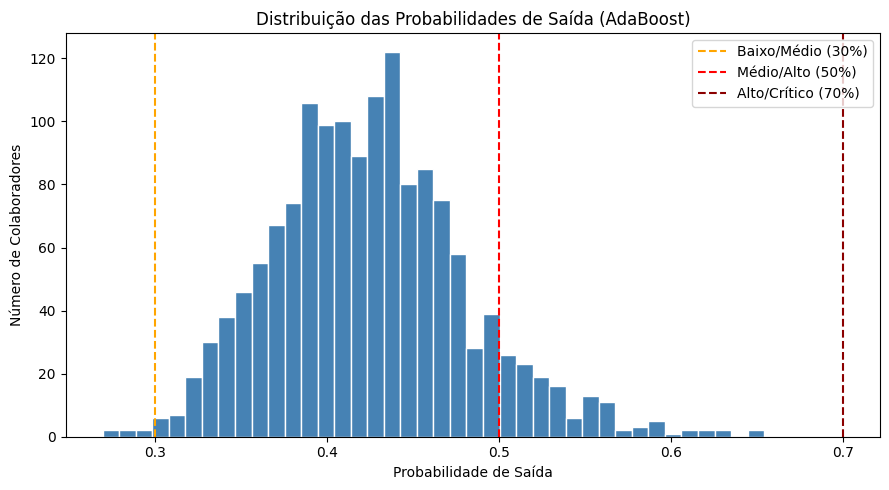

In [100]:
# 73. VISUALIZAÇÕES DO ÍNDICE DE RISCO (ADABOOST)

import matplotlib.pyplot as plt

# 73.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_risco_ada["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Thresholds corretos
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Baixo/Médio (30%)")
ax.axvline(0.50, color="red", linestyle="--", linewidth=1.5, label="Médio/Alto (50%)")
ax.axvline(0.70, color="darkred", linestyle="--", linewidth=1.5, label="Alto/Crítico (70%)")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (AdaBoost)")

ax.legend()

plt.tight_layout()
plt.savefig("distribuicao_probabilidades_ada.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

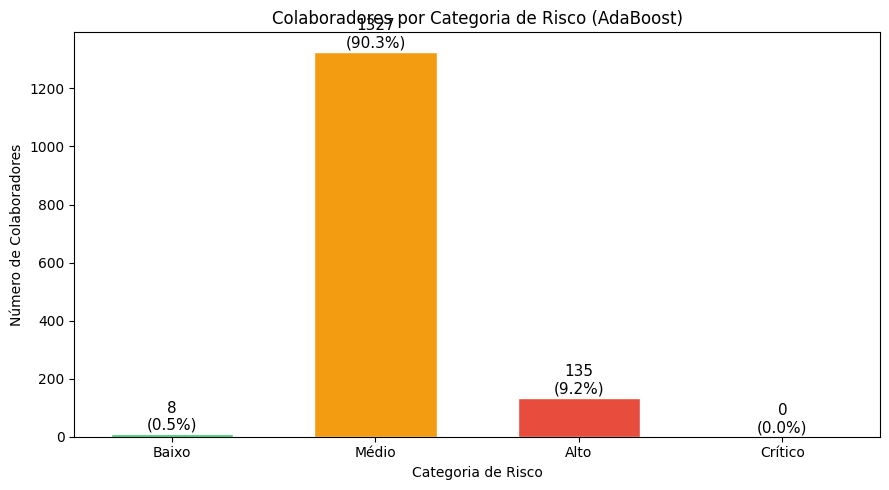

In [101]:
# 73.2 Contagem por categoria (ADABOOST)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = {
    "Baixo": "#2ecc71",
    "Médio": "#f39c12",
    "Alto": "#e74c3c",
    "Crítico": "#8e0000"
}

fig, ax = plt.subplots(figsize=(9, 5))

# Valores das categorias
vals = [contagem_ada.get(c, 0) for c in ORDEM]

bars = ax.bar(
    ORDEM,
    vals,
    color=[cores[c] for c in ORDEM],
    edgecolor="white",
    width=0.6
)

# Labels (nº + %)
for bar, cat in zip(bars, ORDEM):
    n   = contagem_ada.get(cat, 0)
    pct = percentagem_ada.get(cat, 0.0)
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (AdaBoost)")

plt.tight_layout()
plt.savefig("categorias_risco_ada.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

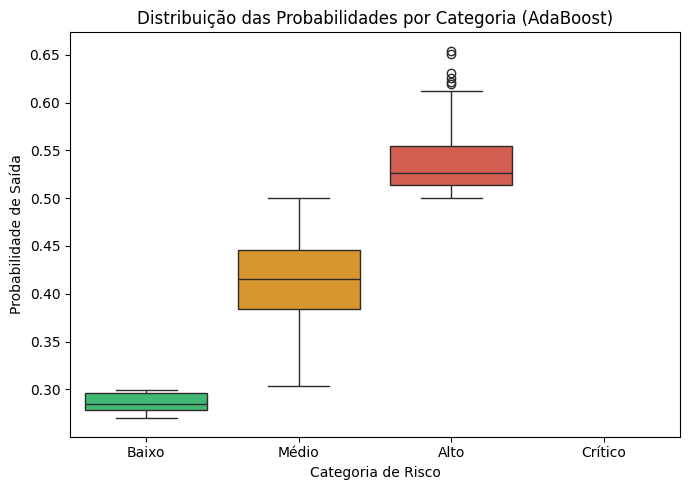

In [102]:
# 73.3 Boxplot por categoria (ADABOOST)

import matplotlib.pyplot as plt
import seaborn as sns

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = ["#2ecc71", "#f39c12", "#e74c3c", "#8e0000"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_risco_ada,
    x="nivel_risco",
    y="prob_saida",
    order=ORDEM,
    palette=cores,
    ax=ax
)

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (AdaBoost)")

plt.tight_layout()
plt.savefig("boxplot_risco_ada.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [103]:
# 74. RESUMO FINAL (ADABOOST)

print("=" * 55)
print("RESUMO — ADABOOST")
print("=" * 55)

print(f"  Modelo:         AdaBoost (100 estimadores)")
print(f"  Colaboradores:  {len(df_risco_ada)}")

print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")

for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"  {nome:<12}  {resultados_treino_ada[metrica]:>8.4f}  {resultados_teste_ada[metrica]:>8.4f}")

print("\n  Distribuição das categorias de risco:")

print(f"  Baixo:    prob < 30%        -> {contagem_ada.get('Baixo', 0)} colaboradores")
print(f"  Médio:    30% ≤ prob < 50%  -> {contagem_ada.get('Médio', 0)} colaboradores")
print(f"  Alto:     50% ≤ prob < 70%  -> {contagem_ada.get('Alto', 0)} colaboradores")
print(f"  Crítico:  prob ≥ 70%        -> {contagem_ada.get('Crítico', 0)} colaboradores")

print("=" * 55)

RESUMO — ADABOOST
  Modelo:         AdaBoost (100 estimadores)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        0.9014    0.8503
  Precision       0.8364    0.5600
  Recall          0.4842    0.2979
  F1-Score        0.6133    0.3889
  AUC-ROC         0.9145    0.8022

  Distribuição das categorias de risco:
  Baixo:    prob < 30%        -> 8 colaboradores
  Médio:    30% ≤ prob < 50%  -> 1327 colaboradores
  Alto:     50% ≤ prob < 70%  -> 135 colaboradores
  Crítico:  prob ≥ 70%        -> 0 colaboradores


## 7. Candidato  - LIGHTGBM (Light Gradient Boosting Machine)

In [104]:
# 75. TREINO — LIGHTGBM
pipeline_lgb = Pipeline([
    ("scaler", StandardScaler()), 
    ("lgb", LGBMClassifier(random_state=42, verbose=-1)) 
])

pipeline_lgb.fit(X_train, y_train)
print("Modelo LightGBM treinado com sucesso!")

Modelo LightGBM treinado com sucesso!


In [105]:
# 76. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (LIGHTGBM)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [106]:
# 76.1 TREINO
resultados_treino_lgb = avaliar_modelo(pipeline_lgb, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [107]:
# 76.2 TESTE
resultados_teste_lgb  = avaliar_modelo(pipeline_lgb, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.3810
  Precision: 0.7500
  Recall:    0.2553
  AUC-ROC:   0.7826

              precision    recall  f1-score   support

  Permaneceu       0.87      0.98      0.93       247
        Saiu       0.75      0.26      0.38        47

    accuracy                           0.87       294
   macro avg       0.81      0.62      0.65       294
weighted avg       0.85      0.87      0.84       294



In [108]:
# 77. COMPARAÇÃO TREINO vs TESTE (LIGHTGBM)

print("===== COMPARAÇÃO TREINO vs TESTE (LIGHTGBM) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário do LightGBM
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_lgb[metrica]
    val_teste  = resultados_teste_lgb[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_lgb = resultados_treino_lgb["f1"] - resultados_teste_lgb["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_lgb > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting (Modelo Estável).")

===== COMPARAÇÃO TREINO vs TESTE (LIGHTGBM) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        1.0000    0.8673     +0.1327
  PRECISION       1.0000    0.7500     +0.2500
  RECALL          1.0000    0.2553     +0.7447
  F1              1.0000    0.3810     +0.6190
  AUC             1.0000    0.7826     +0.2174

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


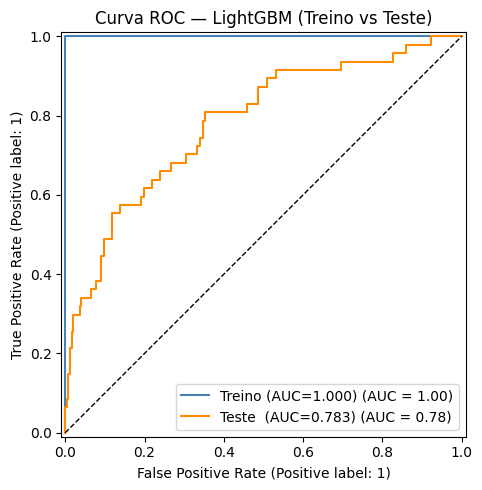

In [109]:
# 78. CURVAS ROC SOBREPOSTAS (LIGHTGBM)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino - Usando os resultados do LightGBM
RocCurveDisplay.from_predictions(
    resultados_treino_lgb["y"], resultados_treino_lgb["y_proba"],
    name=f"Treino (AUC={resultados_treino_lgb['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste - Usando os resultados do LightGBM
RocCurveDisplay.from_predictions(
    resultados_teste_lgb["y"], resultados_teste_lgb["y_proba"],
    name=f"Teste  (AUC={resultados_teste_lgb['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — LightGBM (Treino vs Teste)")
plt.tight_layout()

# Salvando com o nome do modelo atual
plt.savefig("roc_treino_vs_teste_lgb.png", dpi=150, bbox_inches="tight")
plt.show()

In [110]:
# 79. GERAR PROBABILIDADES DE SAÍDA (dataset completo - LIGHTGBM)
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_lgb para não sobrescrever o trabalho do AdaBoost, SVM ou outros
df_risco_lgb = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do LightGBM
df_risco_lgb["prob_saida"] = pipeline_lgb.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_lgb)} colaboradores (LightGBM).")
print(df_risco_lgb["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (LightGBM).
count    1470.0000
mean        0.1461
std         0.3289
min         0.0000
25%         0.0015
50%         0.0056
75%         0.0205
90%         0.9570
max         0.9983
Name: prob_saida, dtype: float64


In [111]:
# 80. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (LIGHTGBM)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

# Aplicar a função ao DataFrame do LightGBM
df_risco_lgb["nivel_risco"] = df_risco_lgb["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem_lgb    = df_risco_lgb["nivel_risco"].value_counts()
percentagem_lgb = df_risco_lgb["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (LIGHTGBM) =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n   = contagem_lgb.get(cat, 0)
    pct = percentagem_lgb.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (LIGHTGBM) =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo          1251        85.1%
Médio            13         0.9%
Alto              8         0.5%
Crítico         198        13.5%


In [112]:
# 81. ANÁLISE POR CATEGORIA DE RISCO (LIGHTGBM)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cols_analise = ["prob_saida", "Attrition_bin"]

# Adicionar variáveis de negócio para caracterizar cada nível de risco
for col in [
    "Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
    "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"
]:
    if col in df_risco_lgb.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (LIGHTGBM) =====")

perfil_lgb = (
    df_risco_lgb
    .groupby("nivel_risco")[cols_analise]
    .mean()
    .reindex(ORDEM)
    .round(3)
)

display(perfil_lgb)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (LIGHTGBM) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.011,0.025,37.622,6819.271,2.141,11.891,0.238,2.201,7.434
Médio,0.356,0.308,35.615,4323.615,1.462,7.538,0.615,2.231,2.154
Alto,0.601,0.750,32.375,4678.125,1.625,7.125,0.875,2.000,3.875
Crítico,0.965,0.990,32.783,4721.056,1.636,7.828,0.520,1.939,4.763


In [113]:
# 82. TOP 20 COLABORADORES COM MAIOR RISCO (LIGHTGBM)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_lgb.columns:
        cols_top.append(col)

# Usar o DataFrame do LightGBM para encontrar os 20 casos mais críticos
top20_lgb = df_risco_lgb.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (LIGHTGBM) =====")
display(top20_lgb)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (LIGHTGBM) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.998324,Crítico,1,26,2340,1,1
1,0.997468,Crítico,1,24,3172,1,1
2,0.996856,Crítico,1,19,2121,1,1
3,0.994328,Crítico,1,31,1359,1,0
4,0.993806,Crítico,1,19,1675,1,1
5,0.992426,Crítico,1,25,2413,1,1
6,0.992322,Crítico,1,32,2432,1,1
7,0.991888,Crítico,1,19,1859,1,1
8,0.991597,Crítico,1,27,2863,1,0
9,0.991125,Crítico,1,19,1102,1,0


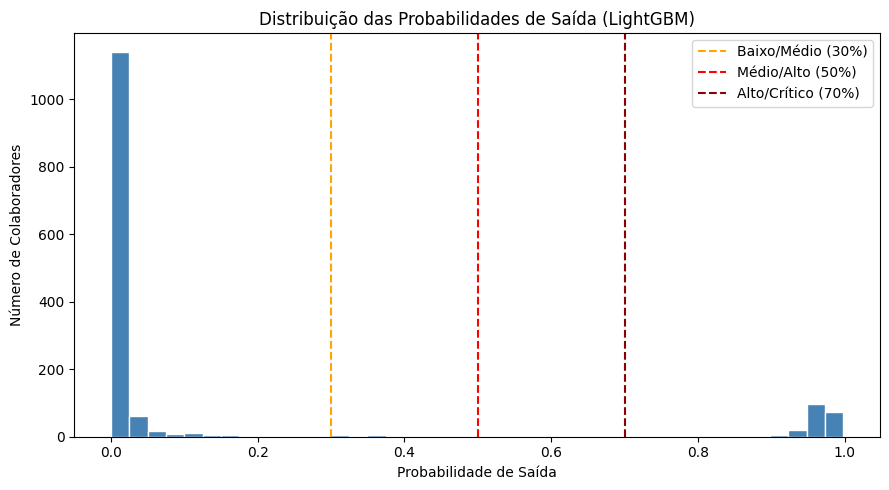

In [114]:
# 83. VISUALIZAÇÕES DO ÍNDICE DE RISCO (LIGHTGBM)

import matplotlib.pyplot as plt

# 83.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_risco_lgb["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Thresholds corretos
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Baixo/Médio (30%)")
ax.axvline(0.50, color="red", linestyle="--", linewidth=1.5, label="Médio/Alto (50%)")
ax.axvline(0.70, color="darkred", linestyle="--", linewidth=1.5, label="Alto/Crítico (70%)")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (LightGBM)")

ax.legend()

plt.tight_layout()
plt.savefig("distribuicao_probabilidades_lgb.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

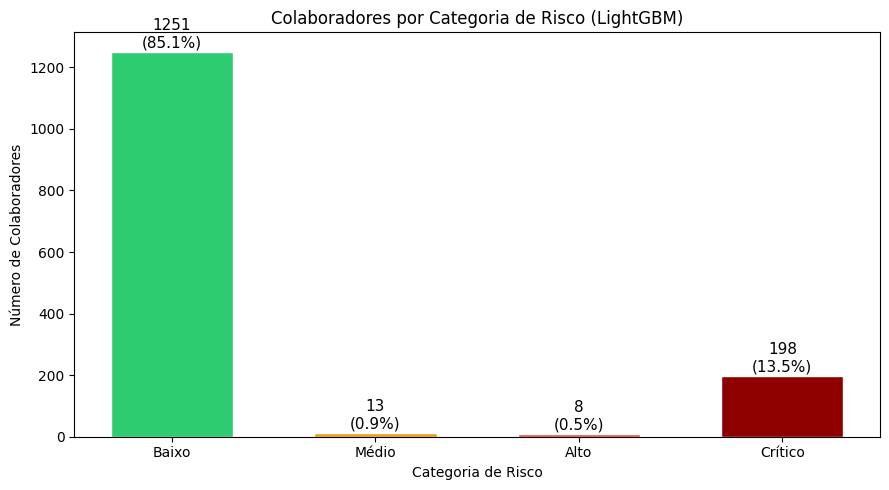

In [115]:
# 83.2 Contagem por categoria (LIGHTGBM)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = {
    "Baixo": "#2ecc71",
    "Médio": "#f39c12",
    "Alto": "#e74c3c",
    "Crítico": "#8e0000"
}

fig, ax = plt.subplots(figsize=(9, 5)) 

vals = [contagem_lgb.get(c, 0) for c in ORDEM]

bars = ax.bar(
    ORDEM,
    vals,
    color=[cores[c] for c in ORDEM],
    edgecolor="white",
    width=0.6
)

for bar, cat in zip(bars, ORDEM):
    n   = contagem_lgb.get(cat, 0)
    pct = percentagem_lgb.get(cat, 0.0)
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (LightGBM)")

plt.tight_layout()
plt.savefig("categorias_risco_lgb.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

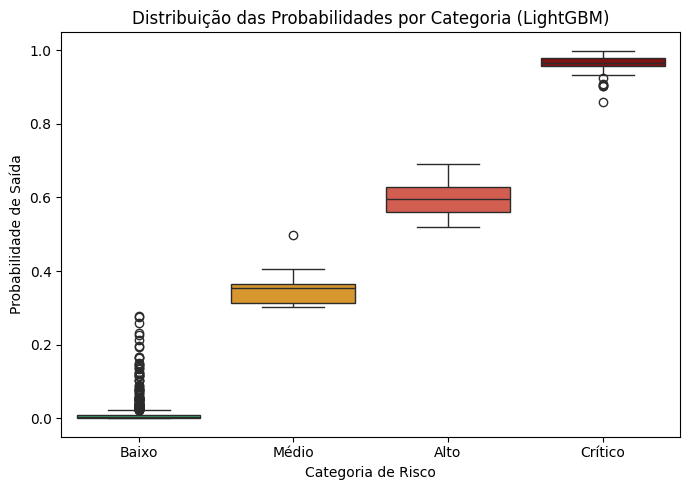

In [116]:
# 83.3 Boxplot por categoria (LIGHTGBM)

import matplotlib.pyplot as plt
import seaborn as sns

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = ["#2ecc71", "#f39c12", "#e74c3c", "#8e0000"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_risco_lgb,
    x="nivel_risco",
    y="prob_saida",
    order=ORDEM,
    palette=cores,
    ax=ax
)

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (LightGBM)")

plt.tight_layout()
plt.savefig("boxplot_risco_lgb.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [117]:
# 84. RESUMO FINAL (LIGHTGBM)

print("=" * 55)
print("RESUMO — LIGHTGBM")
print("=" * 55)

print(f"  Modelo:         LightGBM (100 estimadores)")
print(f"  Colaboradores:  {len(df_risco_lgb)}")

print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")

for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"  {nome:<12}  {resultados_treino_lgb[metrica]:>8.4f}  {resultados_teste_lgb[metrica]:>8.4f}")

print("\n  Distribuição das categorias de risco:")

print(f"  Baixo:    prob < 30%        -> {contagem_lgb.get('Baixo', 0)} colaboradores")
print(f"  Médio:    30% ≤ prob < 50%  -> {contagem_lgb.get('Médio', 0)} colaboradores")
print(f"  Alto:     50% ≤ prob < 70%  -> {contagem_lgb.get('Alto', 0)} colaboradores")
print(f"  Crítico:  prob ≥ 70%        -> {contagem_lgb.get('Crítico', 0)} colaboradores")

print("=" * 55)

RESUMO — LIGHTGBM
  Modelo:         LightGBM (100 estimadores)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        1.0000    0.8673
  Precision       1.0000    0.7500
  Recall          1.0000    0.2553
  F1-Score        1.0000    0.3810
  AUC-ROC         1.0000    0.7826

  Distribuição das categorias de risco:
  Baixo:    prob < 30%        -> 1251 colaboradores
  Médio:    30% ≤ prob < 50%  -> 13 colaboradores
  Alto:     50% ≤ prob < 70%  -> 8 colaboradores
  Crítico:  prob ≥ 70%        -> 198 colaboradores


## 8. Candidato  - XGBOOST

In [118]:
# 85.TREINO — XGBOOST
pipeline_xgb = Pipeline([
    ("scaler", StandardScaler()), 
    ("xgb", XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)) 
])

pipeline_xgb.fit(X_train, y_train)
print("Modelo XGBoost treinado com sucesso!")

Modelo XGBoost treinado com sucesso!


In [119]:
# 86. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (XGBOOST)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [120]:
# 86.1 TREINO
resultados_treino_xgb = avaliar_modelo(pipeline_xgb, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [121]:
# 86.2 TESTE
resultados_teste_xgb  = avaliar_modelo(pipeline_xgb, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.3333
  Precision: 0.5789
  Recall:    0.2340
  AUC-ROC:   0.7617

              precision    recall  f1-score   support

  Permaneceu       0.87      0.97      0.92       247
        Saiu       0.58      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.72      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294



In [122]:
# 87. COMPARAÇÃO TREINO vs TESTE (XGBOOST)

print("===== COMPARAÇÃO TREINO vs TESTE (XGBOOST) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário do XGBoost
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_xgb[metrica]
    val_teste  = resultados_teste_xgb[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_xgb = resultados_treino_xgb["f1"] - resultados_teste_xgb["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_xgb > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting (Modelo Estável).")

===== COMPARAÇÃO TREINO vs TESTE (XGBOOST) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        1.0000    0.8503     +0.1497
  PRECISION       1.0000    0.5789     +0.4211
  RECALL          1.0000    0.2340     +0.7660
  F1              1.0000    0.3333     +0.6667
  AUC             1.0000    0.7617     +0.2383

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


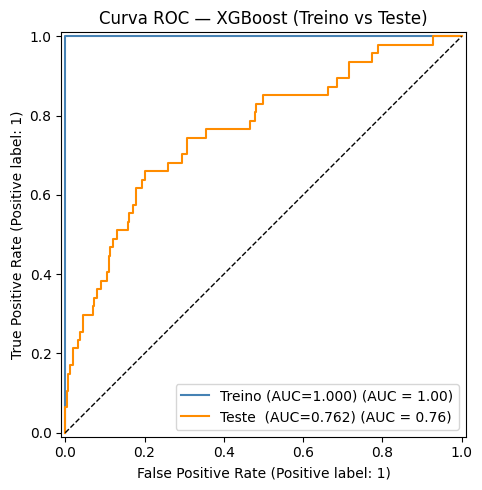

In [123]:
# 88. CURVAS ROC SOBREPOSTAS (XGBOOST)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino - Usando os resultados do XGBoost
RocCurveDisplay.from_predictions(
    resultados_treino_xgb["y"], resultados_treino_xgb["y_proba"],
    name=f"Treino (AUC={resultados_treino_xgb['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste - Usando os resultados do XGBoost
RocCurveDisplay.from_predictions(
    resultados_teste_xgb["y"], resultados_teste_xgb["y_proba"],
    name=f"Teste  (AUC={resultados_teste_xgb['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — XGBoost (Treino vs Teste)")
plt.tight_layout()

# Salvando com o nome do modelo atual
plt.savefig("roc_treino_vs_teste_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

In [124]:
# 89. GERAR PROBABILIDADES DE SAÍDA (dataset completo - XGBOOST)
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_xgb para não sobrescrever o trabalho do LightGBM, AdaBoost ou outros
df_risco_xgb = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do XGBoost
df_risco_xgb["prob_saida"] = pipeline_xgb.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_xgb)} colaboradores (XGBoost).")
print(df_risco_xgb["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (XGBoost).
count    1470.0000
mean        0.1469
std         0.3313
min         0.0000
25%         0.0012
50%         0.0048
75%         0.0190
90%         0.9549
max         0.9999
Name: prob_saida, dtype: float64


In [125]:
# 90. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (XGBOOST)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

# Aplicar a função ao DataFrame do XGBoost
df_risco_xgb["nivel_risco"] = df_risco_xgb["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem_xgb    = df_risco_xgb["nivel_risco"].value_counts()
percentagem_xgb = df_risco_xgb["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (XGBOOST) =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n   = contagem_xgb.get(cat, 0)
    pct = percentagem_xgb.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (XGBOOST) =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo          1250        85.0%
Médio            11         0.7%
Alto              7         0.5%
Crítico         202        13.7%


In [126]:
# 91. ANÁLISE POR CATEGORIA DE RISCO (XGBOOST)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cols_analise = ["prob_saida", "Attrition_bin"]

# Adicionar variáveis de negócio para caracterizar cada nível de risco
for col in [
    "Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
    "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"
]:
    if col in df_risco_xgb.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (XGBOOST) =====")

perfil_xgb = (
    df_risco_xgb
    .groupby("nivel_risco")[cols_analise]
    .mean()
    .reindex(ORDEM)
    .round(3)
)

display(perfil_xgb)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (XGBOOST) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.010,0.026,37.649,6830.056,2.142,11.911,0.242,2.203,7.434
Médio,0.398,0.273,32.727,3972.182,1.545,5.273,0.364,2.455,2.636
Alto,0.569,0.429,33.429,2776.857,1.000,8.000,0.571,1.429,4.000
Crítico,0.964,0.980,32.787,4745.579,1.644,7.812,0.525,1.941,4.718


In [127]:
# 92. TOP 20 COLABORADORES COM MAIOR RISCO (XGBOOST)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_xgb.columns:
        cols_top.append(col)

# Usar o DataFrame do XGBoost para encontrar os 20 casos mais críticos
top20_xgb = df_risco_xgb.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (XGBOOST) =====")
display(top20_xgb)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (XGBOOST) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.999875,Crítico,1,24,3172,1,1
1,0.999808,Crítico,1,26,2340,1,1
2,0.999530,Crítico,1,19,2121,1,1
3,0.999456,Crítico,1,31,1359,1,0
4,0.999355,Crítico,1,25,1118,1,1
5,0.998342,Crítico,1,19,1675,1,1
6,0.997991,Crítico,1,27,2863,1,0
7,0.997580,Crítico,1,29,2404,1,1
8,0.997489,Crítico,1,25,2413,1,1
9,0.996920,Crítico,1,39,3646,1,1


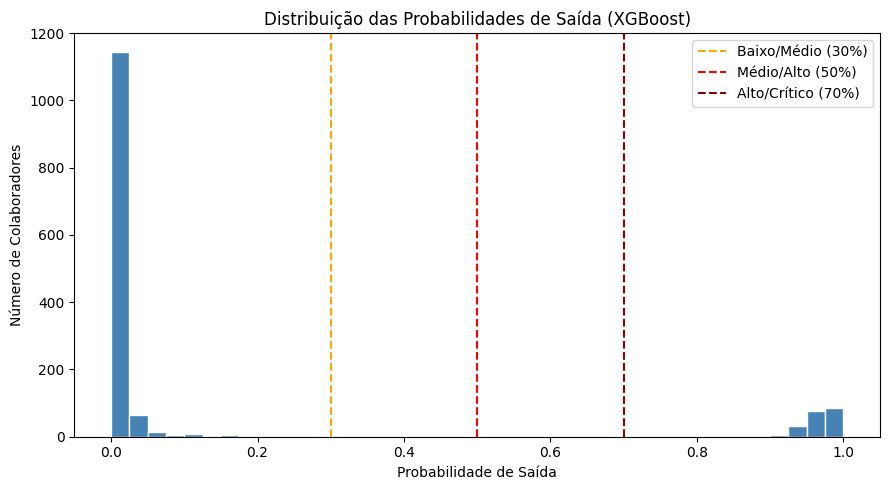

In [128]:
# 93. VISUALIZAÇÕES DO ÍNDICE DE RISCO (XGBOOST)

import matplotlib.pyplot as plt

# 93.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_risco_xgb["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Thresholds corretos
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Baixo/Médio (30%)")
ax.axvline(0.50, color="red", linestyle="--", linewidth=1.5, label="Médio/Alto (50%)")
ax.axvline(0.70, color="darkred", linestyle="--", linewidth=1.5, label="Alto/Crítico (70%)")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (XGBoost)")

ax.legend()

plt.tight_layout()
plt.savefig("distribuicao_probabilidades_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

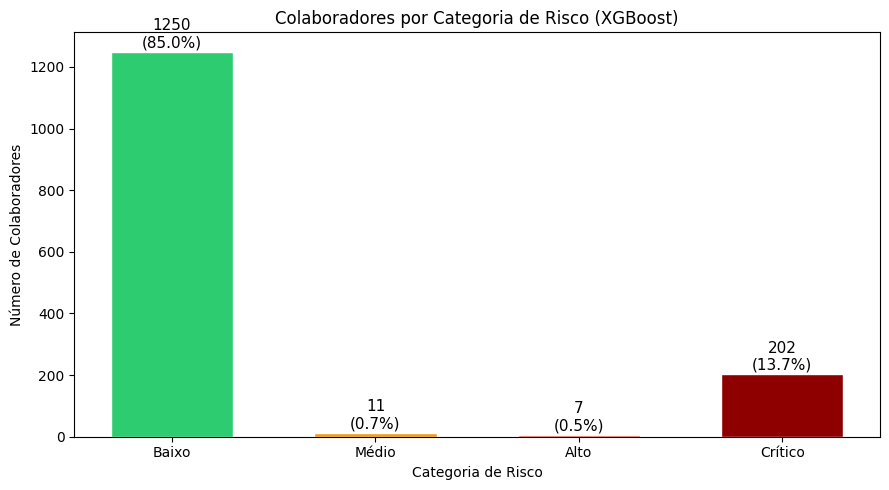

In [129]:
# 93.2 Contagem por categoria (XGBOOST)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = {
    "Baixo": "#2ecc71",
    "Médio": "#f39c12",
    "Alto": "#e74c3c",
    "Crítico": "#8e0000"
}

fig, ax = plt.subplots(figsize=(9, 5)) 

# Valores das categorias
vals = [contagem_xgb.get(c, 0) for c in ORDEM]

bars = ax.bar(
    ORDEM,
    vals,
    color=[cores[c] for c in ORDEM],
    edgecolor="white",
    width=0.6
)

# Labels (nº + %)
for bar, cat in zip(bars, ORDEM):
    n   = contagem_xgb.get(cat, 0)
    pct = percentagem_xgb.get(cat, 0.0)
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (XGBoost)")

plt.tight_layout()
plt.savefig("categorias_risco_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

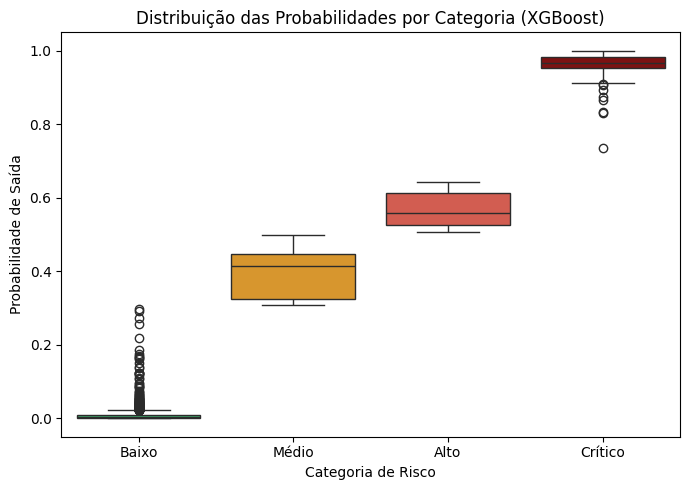

In [130]:
# 93.3 Boxplot por categoria (XGBOOST)

import matplotlib.pyplot as plt
import seaborn as sns

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = ["#2ecc71", "#f39c12", "#e74c3c", "#8e0000"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_risco_xgb,
    x="nivel_risco",
    y="prob_saida",
    order=ORDEM,
    palette=cores,
    ax=ax
)

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (XGBoost)")

plt.tight_layout()
plt.savefig("boxplot_risco_xgb.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [131]:
# 94. RESUMO FINAL (XGBOOST)

print("=" * 55)
print("RESUMO — XGBOOST")
print("=" * 55)

print(f"  Modelo:         XGBoost (100 estimadores)")
print(f"  Colaboradores:  {len(df_risco_xgb)}")

print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")

for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"  {nome:<12}  {resultados_treino_xgb[metrica]:>8.4f}  {resultados_teste_xgb[metrica]:>8.4f}")

print("\n  Distribuição das categorias de risco:")

print(f"  Baixo:    prob < 30%        -> {contagem_xgb.get('Baixo', 0)} colaboradores")
print(f"  Médio:    30% ≤ prob < 50%  -> {contagem_xgb.get('Médio', 0)} colaboradores")
print(f"  Alto:     50% ≤ prob < 70%  -> {contagem_xgb.get('Alto', 0)} colaboradores")
print(f"  Crítico:  prob ≥ 70%        -> {contagem_xgb.get('Crítico', 0)} colaboradores")

print("=" * 55)

RESUMO — XGBOOST
  Modelo:         XGBoost (100 estimadores)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        1.0000    0.8503
  Precision       1.0000    0.5789
  Recall          1.0000    0.2340
  F1-Score        1.0000    0.3333
  AUC-ROC         1.0000    0.7617

  Distribuição das categorias de risco:
  Baixo:    prob < 30%        -> 1250 colaboradores
  Médio:    30% ≤ prob < 50%  -> 11 colaboradores
  Alto:     50% ≤ prob < 70%  -> 7 colaboradores
  Crítico:  prob ≥ 70%        -> 202 colaboradores


## 9. Candidato  - RANDOM FOREST

In [132]:
# 95. TREINO — RANDOM FOREST

pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)) 
])

pipeline_rf.fit(X_train, y_train)
print("Modelo Random Forest treinado com sucesso!")

Modelo Random Forest treinado com sucesso!


In [133]:
# 96. AVALIAÇÃO NO CONJUNTO DE TREINO E TESTE (RANDOM FOREST)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Nota: A função 'avaliar_modelo' já foi definida anteriormente, 
# mas mantemo-la aqui para garantir que o código é autoexecutável.

def avaliar_modelo(pipeline, X, y, nome_conjunto):
    y_pred       = pipeline.predict(X)
    y_pred_proba = pipeline.predict_proba(X)[:, 1]

    acc       = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall    = recall_score(y, y_pred)
    f1        = f1_score(y, y_pred)
    auc       = roc_auc_score(y, y_pred_proba)

    print(f"===== METRICAS — {nome_conjunto} =====")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print()
    print(classification_report(y, y_pred, target_names=["Permaneceu", "Saiu"]))

    return {
        "conjunto":  nome_conjunto,
        "acc":       acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
        "auc":       auc,
        "y":         y,
        "y_proba":   y_pred_proba
    }

In [134]:
# 96.1 TREINO
resultados_treino_rf = avaliar_modelo(pipeline_rf, X_train, y_train, "Treino")

===== METRICAS — Treino =====
  F1-Score:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  AUC-ROC:   1.0000

              precision    recall  f1-score   support

  Permaneceu       1.00      1.00      1.00       986
        Saiu       1.00      1.00      1.00       190

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



In [135]:
# 96.2 TESTE
resultados_teste_rf  = avaliar_modelo(pipeline_rf, X_test,  y_test,  "Teste")

===== METRICAS — Teste =====
  F1-Score:  0.1724
  Precision: 0.4545
  Recall:    0.1064
  AUC-ROC:   0.7932

              precision    recall  f1-score   support

  Permaneceu       0.85      0.98      0.91       247
        Saiu       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



In [136]:
# 97. COMPARAÇÃO TREINO vs TESTE (RANDOM FOREST)

print("===== COMPARAÇÃO TREINO vs TESTE (RANDOM FOREST) =====")
print(f"  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}  {'Diferença':>10}")
print(f"  {'-'*44}")

# Iterar sobre as métricas guardadas no dicionário do Random Forest
for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    val_treino = resultados_treino_rf[metrica]
    val_teste  = resultados_teste_rf[metrica]
    diff       = val_treino - val_teste
    
    # Formatação do nome da métrica
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"  {nome:<12}  {val_treino:>8.4f}  {val_teste:>8.4f}  {diff:>+10.4f}")

# Validação automática de Overfitting focada no F1-Score
diff_f1_rf = resultados_treino_rf["f1"] - resultados_teste_rf["f1"]

print() # Linha em branco para limpeza visual
if diff_f1_rf > 0.10:
    print("  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.")
else:
    print("  --> Sem sinais evidentes de overfitting (Modelo Estável).")

===== COMPARAÇÃO TREINO vs TESTE (RANDOM FOREST) =====
  Métrica         Treino     Teste   Diferença
  --------------------------------------------
  Accuracy        1.0000    0.8367     +0.1633
  PRECISION       1.0000    0.4545     +0.5455
  RECALL          1.0000    0.1064     +0.8936
  F1              1.0000    0.1724     +0.8276
  AUC             1.0000    0.7932     +0.2068

  --> Sinal de OVERFITTING: o modelo decorou o treino mas generaliza mal.


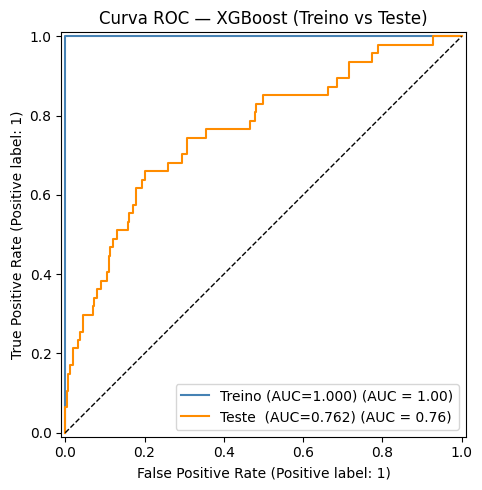

In [137]:
# 98. CURVAS ROC SOBREPOSTAS (XGBOOST)
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

# Curva de Treino - Usando os resultados do XGBoost
RocCurveDisplay.from_predictions(
    resultados_treino_xgb["y"], resultados_treino_xgb["y_proba"],
    name=f"Treino (AUC={resultados_treino_xgb['auc']:.3f})", ax=ax, color="steelblue"
)

# Curva de Teste - Usando os resultados do XGBoost
RocCurveDisplay.from_predictions(
    resultados_teste_xgb["y"], resultados_teste_xgb["y_proba"],
    name=f"Teste  (AUC={resultados_teste_xgb['auc']:.3f})", ax=ax, color="darkorange"
)

# Linha de referência (o "acaso")
ax.plot([0, 1], [0, 1], "k--", lw=1)

ax.set_title("Curva ROC — XGBoost (Treino vs Teste)")
plt.tight_layout()

# Salvando com o nome do modelo atual
plt.savefig("roc_treino_vs_teste_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

In [138]:
# 99. GERAR PROBABILIDADES DE SAÍDA (dataset completo - RANDOM FOREST)
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
df_completo = pd.read_csv(url)

# Aplicar a mesma preparação de features
cols_remover = ["Attrition", "OverTime", "Gender", "BusinessTravel", 
                "Department", "EducationField", "JobRole", "MaritalStatus"]
cols_remover = [c for c in cols_remover if c in df_completo.columns]

# Evitar erros caso a Attrition_bin não esteja no CSV
X_completo = df_completo.drop(columns=cols_remover + ["Attrition_bin"], errors='ignore')
X_completo = X_completo.select_dtypes(include=[np.number])

# Usamos df_risco_rf para não sobrescrever o trabalho do XGBoost, LightGBM ou outros
df_risco_rf = df_completo.copy()

# A MUDANÇA PRINCIPAL: Chamar o pipeline do Random Forest
df_risco_rf["prob_saida"] = pipeline_rf.predict_proba(X_completo)[:, 1]

print(f"Probabilidades geradas para {len(df_risco_rf)} colaboradores (Random Forest).")
print(df_risco_rf["prob_saida"].describe(percentiles=[.25, .50, .75, .90]).round(4))

Probabilidades geradas para 1470 colaboradores (Random Forest).
count    1470.0000
mean        0.1663
std         0.2423
min         0.0000
25%         0.0300
50%         0.0600
75%         0.1400
90%         0.6800
max         0.9600
Name: prob_saida, dtype: float64


In [139]:
# 100. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO (RANDOM FOREST)

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

# Aplicar a função ao DataFrame do Random Forest
df_risco_rf["nivel_risco"] = df_risco_rf["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem_rf    = df_risco_rf["nivel_risco"].value_counts()
percentagem_rf = df_risco_rf["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (RANDOM FOREST) =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n   = contagem_rf.get(cat, 0)
    pct = percentagem_rf.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO (RANDOM FOREST) =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo          1234        83.9%
Médio            34         2.3%
Alto             66         4.5%
Crítico         136         9.3%


In [140]:
# 101. ANÁLISE POR CATEGORIA DE RISCO (RANDOM FOREST)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cols_analise = ["prob_saida", "Attrition_bin"]

# Adicionar variáveis de negócio para caracterizar cada nível de risco
for col in [
    "Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
    "OverTime_bin", "SatisfactionIndex", "YearsAtCompany"
]:
    if col in df_risco_rf.columns:
        cols_analise.append(col)

print("\n===== PERFIL MÉDIO POR CATEGORIA DE RISCO (RANDOM FOREST) =====")

perfil_rf = (
    df_risco_rf
    .groupby("nivel_risco")[cols_analise]
    .mean()
    .reindex(ORDEM)
    .round(3)
)

display(perfil_rf)


===== PERFIL MÉDIO POR CATEGORIA DE RISCO (RANDOM FOREST) =====


,prob_saida,Attrition_bin,Age,MonthlyIncome,JobLevel,TotalWorkingYears,OverTime_bin,SatisfactionIndex,YearsAtCompany
nivel_risco,,,,,,,,,
Baixo,0.067,0.021,37.780,6880.180,2.156,12.011,0.236,2.201,7.507
Médio,0.364,0.471,31.735,3736.618,1.324,6.147,0.647,2.088,2.794
Alto,0.646,0.909,36.848,6077.045,1.985,10.409,0.409,2.000,6.742
Crítico,0.788,0.993,30.493,3978.213,1.449,6.346,0.559,1.941,3.662


In [141]:
# 102. TOP 20 COLABORADORES COM MAIOR RISCO (RANDOM FOREST)

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco_rf.columns:
        cols_top.append(col)

# Usar o DataFrame do Random Forest para encontrar os 20 casos mais críticos
top20_rf = df_risco_rf.nlargest(20, "prob_saida")[cols_top].reset_index(drop=True)

print("\n===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (RANDOM FOREST) =====")
display(top20_rf)


===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA (RANDOM FOREST) =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
0,0.96,Crítico,1,21,1416,1,0
1,0.95,Crítico,1,26,2340,1,1
2,0.93,Crítico,1,18,1878,1,1
3,0.93,Crítico,1,18,1569,1,1
4,0.93,Crítico,1,29,1091,1,0
5,0.92,Crítico,1,19,1675,1,1
6,0.92,Crítico,1,31,1359,1,0
7,0.92,Crítico,1,27,2863,1,0
8,0.91,Crítico,1,19,2325,1,0
9,0.91,Crítico,1,21,2679,1,0


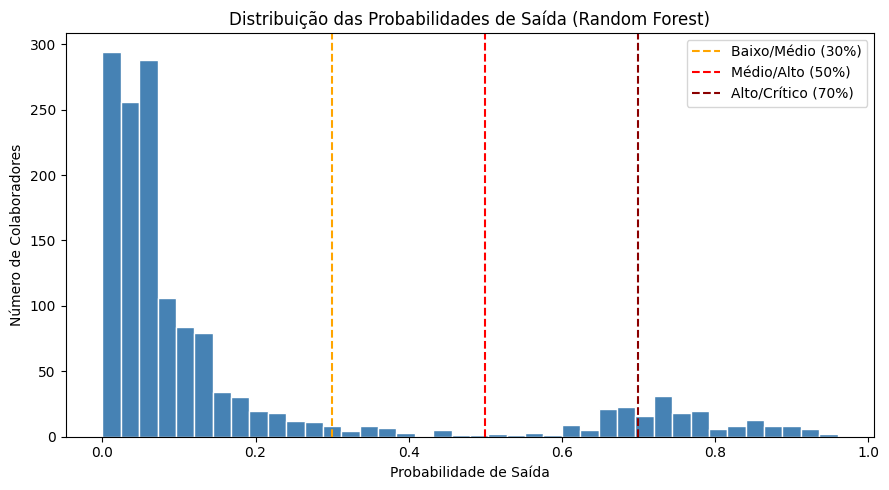

In [142]:
# 103. VISUALIZAÇÕES DO ÍNDICE DE RISCO (RANDOM FOREST)

import matplotlib.pyplot as plt

# 103.1 Histograma das probabilidades
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_risco_rf["prob_saida"], bins=40, color="steelblue", edgecolor="white")

# Thresholds corretos
ax.axvline(0.30, color="orange", linestyle="--", linewidth=1.5, label="Baixo/Médio (30%)")
ax.axvline(0.50, color="red", linestyle="--", linewidth=1.5, label="Médio/Alto (50%)")
ax.axvline(0.70, color="darkred", linestyle="--", linewidth=1.5, label="Alto/Crítico (70%)")

ax.set_xlabel("Probabilidade de Saída")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Distribuição das Probabilidades de Saída (Random Forest)")

ax.legend()

plt.tight_layout()
plt.savefig("distribuicao_probabilidades_rf.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

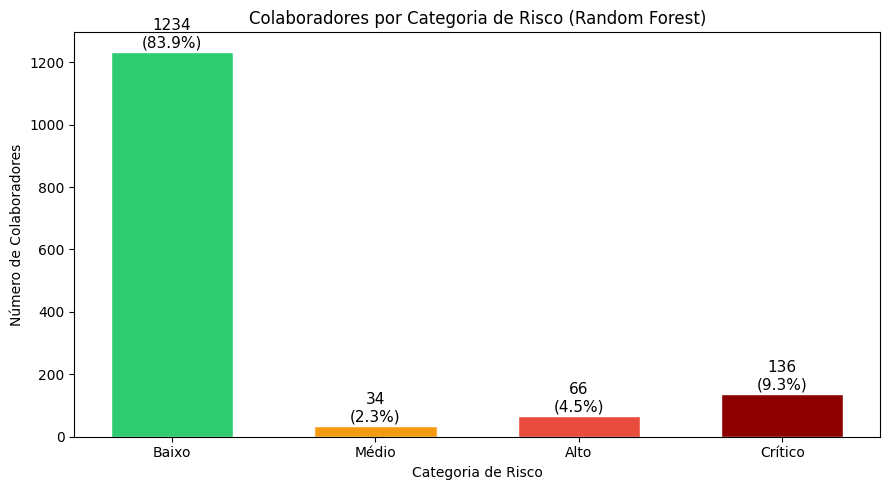

In [143]:
# 103.2 Contagem por categoria (RANDOM FOREST)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = {
    "Baixo": "#2ecc71",
    "Médio": "#f39c12",
    "Alto": "#e74c3c",
    "Crítico": "#8e0000"
}

fig, ax = plt.subplots(figsize=(9, 5)) 

# Valores das categorias
vals = [contagem_rf.get(c, 0) for c in ORDEM]

bars = ax.bar(
    ORDEM,
    vals,
    color=[cores[c] for c in ORDEM],
    edgecolor="white",
    width=0.6
)

# Labels (nº + %)
for bar, cat in zip(bars, ORDEM):
    n   = contagem_rf.get(cat, 0)
    pct = percentagem_rf.get(cat, 0.0)
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{n}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Número de Colaboradores")
ax.set_title("Colaboradores por Categoria de Risco (Random Forest)")

plt.tight_layout()
plt.savefig("categorias_risco_rf.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

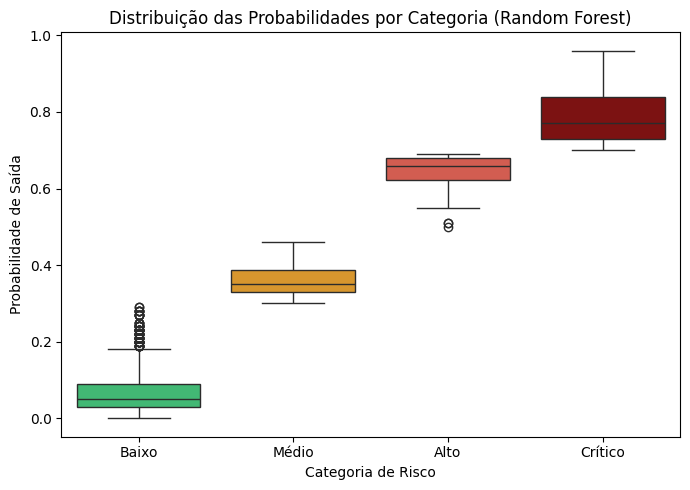

In [144]:
# 103.3 Boxplot por categoria (RANDOM FOREST)

import matplotlib.pyplot as plt
import seaborn as sns

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

cores = ["#2ecc71", "#f39c12", "#e74c3c", "#8e0000"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_risco_rf,
    x="nivel_risco",
    y="prob_saida",
    order=ORDEM,
    palette=cores,
    ax=ax
)

ax.set_xlabel("Categoria de Risco")
ax.set_ylabel("Probabilidade de Saída")
ax.set_title("Distribuição das Probabilidades por Categoria (Random Forest)")

plt.tight_layout()
plt.savefig("boxplot_risco_rf.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [145]:
# 104. RESUMO FINAL (RANDOM FOREST)

print("=" * 55)
print("RESUMO — RANDOM FOREST")
print("=" * 55)

print(f"  Modelo:         Random Forest (100 estimadores)")
print(f"  Colaboradores:  {len(df_risco_rf)}")

print(f"\n  {'Métrica':<12}  {'Treino':>8}  {'Teste':>8}")
print(f"  {'-'*32}")

for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"  {nome:<12}  {resultados_treino_rf[metrica]:>8.4f}  {resultados_teste_rf[metrica]:>8.4f}")

print("\n  Distribuição das categorias de risco:")

print(f"  Baixo:    prob < 30%        -> {contagem_rf.get('Baixo', 0)} colaboradores")
print(f"  Médio:    30% ≤ prob < 50%  -> {contagem_rf.get('Médio', 0)} colaboradores")
print(f"  Alto:     50% ≤ prob < 70%  -> {contagem_rf.get('Alto', 0)} colaboradores")
print(f"  Crítico:  prob ≥ 70%        -> {contagem_rf.get('Crítico', 0)} colaboradores")

print("=" * 55)

RESUMO — RANDOM FOREST
  Modelo:         Random Forest (100 estimadores)
  Colaboradores:  1470

  Métrica         Treino     Teste
  --------------------------------
  Accuracy        1.0000    0.8367
  Precision       1.0000    0.4545
  Recall          1.0000    0.1064
  F1-Score        1.0000    0.1724
  AUC-ROC         1.0000    0.7932

  Distribuição das categorias de risco:
  Baixo:    prob < 30%        -> 1234 colaboradores
  Médio:    30% ≤ prob < 50%  -> 34 colaboradores
  Alto:     50% ≤ prob < 70%  -> 66 colaboradores
  Crítico:  prob ≥ 70%        -> 136 colaboradores


# Melhor Modelo

In [146]:
# 105. TABELA COMPARATIVA 


# 1. RE-TREINAR TUDO 
pipeline_lr  = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(random_state=42))])
pipeline_lr.fit(X_train, y_train)

clf_nb       = GaussianNB()
clf_nb.fit(X_train, y_train)

clf_lda      = LinearDiscriminantAnalysis()
clf_lda.fit(X_train, y_train)

pipeline_knn = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
pipeline_knn.fit(X_train, y_train)

clf_et       = ExtraTreesClassifier(random_state=42)
clf_et.fit(X_train, y_train)

pipeline_svm = Pipeline([("scaler", StandardScaler()), ("svm", SVC(probability=True, random_state=42))])
pipeline_svm.fit(X_train, y_train)

pipeline_ada = Pipeline([("scaler", StandardScaler()), ("ada", AdaBoostClassifier(n_estimators=100, random_state=42))])
pipeline_ada.fit(X_train, y_train)

clf_lgbm     = LGBMClassifier(random_state=42, verbose=-1)
clf_lgbm.fit(X_train, y_train)

clf_xgb      = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
clf_xgb.fit(X_train, y_train)

clf_rf       = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train, y_train)

print("Modelos treinados! A gerar a Tabela Comparativa...\n")

# 2. GERAR A TABELA COMPARATIVA
tabela_comparativa = pd.DataFrame([
    {"Modelo": "Baseline — Regressão Logística",
     "F1 Treino":        f1_score(y_train,        pipeline_lr.predict(X_train)),
     "Precision Treino": precision_score(y_train, pipeline_lr.predict(X_train)),
     "Recall Treino":    recall_score(y_train,    pipeline_lr.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,   pipeline_lr.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,         pipeline_lr.predict(X_test)),
     "Precision Teste":  precision_score(y_test,  pipeline_lr.predict(X_test)),
     "Recall Teste":     recall_score(y_test,     pipeline_lr.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,    pipeline_lr.predict_proba(X_test)[:, 1])},

    {"Modelo": "1. Naive Bayes",
     "F1 Treino":        f1_score(y_train,        clf_nb.predict(X_train)),
     "Precision Treino": precision_score(y_train, clf_nb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,    clf_nb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,   clf_nb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,         clf_nb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,  clf_nb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,     clf_nb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,    clf_nb.predict_proba(X_test)[:, 1])},

    {"Modelo": "2. LDA",
     "F1 Treino":        f1_score(y_train,        clf_lda.predict(X_train)),
     "Precision Treino": precision_score(y_train, clf_lda.predict(X_train)),
     "Recall Treino":    recall_score(y_train,    clf_lda.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,   clf_lda.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,         clf_lda.predict(X_test)),
     "Precision Teste":  precision_score(y_test,  clf_lda.predict(X_test)),
     "Recall Teste":     recall_score(y_test,     clf_lda.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,    clf_lda.predict_proba(X_test)[:, 1])},

    {"Modelo": "3. KNN",
     "F1 Treino":        f1_score(y_train,        pipeline_knn.predict(X_train)),
     "Precision Treino": precision_score(y_train, pipeline_knn.predict(X_train)),
     "Recall Treino":    recall_score(y_train,    pipeline_knn.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,   pipeline_knn.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,         pipeline_knn.predict(X_test)),
     "Precision Teste":  precision_score(y_test,  pipeline_knn.predict(X_test)),
     "Recall Teste":     recall_score(y_test,     pipeline_knn.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,    pipeline_knn.predict_proba(X_test)[:, 1])},

    {"Modelo": "4. Extra Trees",
     "F1 Treino":        f1_score(y_train,        clf_et.predict(X_train)),
     "Precision Treino": precision_score(y_train, clf_et.predict(X_train)),
     "Recall Treino":    recall_score(y_train,    clf_et.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,   clf_et.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,         clf_et.predict(X_test)),
     "Precision Teste":  precision_score(y_test,  clf_et.predict(X_test)),
     "Recall Teste":     recall_score(y_test,     clf_et.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,    clf_et.predict_proba(X_test)[:, 1])},

    {"Modelo": "5. SVM",
     "F1 Treino":        f1_score(y_train,        pipeline_svm.predict(X_train)),
     "Precision Treino": precision_score(y_train, pipeline_svm.predict(X_train)),
     "Recall Treino":    recall_score(y_train,    pipeline_svm.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,   pipeline_svm.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,         pipeline_svm.predict(X_test)),
     "Precision Teste":  precision_score(y_test,  pipeline_svm.predict(X_test)),
     "Recall Teste":     recall_score(y_test,     pipeline_svm.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,    pipeline_svm.predict_proba(X_test)[:, 1])},

    {"Modelo": "6. AdaBoost",
     "F1 Treino":        f1_score(y_train,        pipeline_ada.predict(X_train)),
     "Precision Treino": precision_score(y_train, pipeline_ada.predict(X_train)),
     "Recall Treino":    recall_score(y_train,    pipeline_ada.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,   pipeline_ada.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,         pipeline_ada.predict(X_test)),
     "Precision Teste":  precision_score(y_test,  pipeline_ada.predict(X_test)),
     "Recall Teste":     recall_score(y_test,     pipeline_ada.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,    pipeline_ada.predict_proba(X_test)[:, 1])},

    {"Modelo": "7. LightGBM",
     "F1 Treino":        f1_score(y_train,        clf_lgbm.predict(X_train)),
     "Precision Treino": precision_score(y_train, clf_lgbm.predict(X_train)),
     "Recall Treino":    recall_score(y_train,    clf_lgbm.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,   clf_lgbm.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,         clf_lgbm.predict(X_test)),
     "Precision Teste":  precision_score(y_test,  clf_lgbm.predict(X_test)),
     "Recall Teste":     recall_score(y_test,     clf_lgbm.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,    clf_lgbm.predict_proba(X_test)[:, 1])},

    {"Modelo": "8. XGBoost",
     "F1 Treino":        f1_score(y_train,        clf_xgb.predict(X_train)),
     "Precision Treino": precision_score(y_train, clf_xgb.predict(X_train)),
     "Recall Treino":    recall_score(y_train,    clf_xgb.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,   clf_xgb.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,         clf_xgb.predict(X_test)),
     "Precision Teste":  precision_score(y_test,  clf_xgb.predict(X_test)),
     "Recall Teste":     recall_score(y_test,     clf_xgb.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,    clf_xgb.predict_proba(X_test)[:, 1])},

    {"Modelo": "9. Random Forest",
     "F1 Treino":        f1_score(y_train,        clf_rf.predict(X_train)),
     "Precision Treino": precision_score(y_train, clf_rf.predict(X_train)),
     "Recall Treino":    recall_score(y_train,    clf_rf.predict(X_train)),
     "AUC Treino":       roc_auc_score(y_train,   clf_rf.predict_proba(X_train)[:, 1]),
     "F1 Teste":         f1_score(y_test,         clf_rf.predict(X_test)),
     "Precision Teste":  precision_score(y_test,  clf_rf.predict(X_test)),
     "Recall Teste":     recall_score(y_test,     clf_rf.predict(X_test)),
     "AUC Teste":        roc_auc_score(y_test,    clf_rf.predict_proba(X_test)[:, 1])}
]).round(4)

# Coluna de overfitting 
tabela_comparativa["Overfitting (F1)"] = (
    tabela_comparativa["F1 Treino"] - tabela_comparativa["F1 Teste"]
).round(4).apply(lambda x: f"{x:+.4f} " if x > 0.10 else f"{x:+.4f} ✓")

# Ordenar pelo F1 de Teste 
tabela_comparativa = tabela_comparativa.sort_values("F1 Teste", ascending=False).reset_index(drop=True)

print("===== TABELA COMPARATIVA — TODOS OS MODELOS =====")
display(tabela_comparativa)

# O modelo vencedor
melhor = tabela_comparativa.iloc[0]
print(f"\n Modelo vencedor: {melhor['Modelo']}")
print(f"  F1 Treino:         {melhor['F1 Treino']:.4f}")
print(f"  F1 Teste:          {melhor['F1 Teste']:.4f}")
print(f"  AUC-ROC Teste:     {melhor['AUC Teste']:.4f}")
print(f"  Overfitting (F1):  {melhor['Overfitting (F1)']}")

Modelos treinados! A gerar a Tabela Comparativa...

===== TABELA COMPARATIVA — TODOS OS MODELOS =====


,Modelo,F1 Treino,Precision Treino,Recall Treino,AUC Treino,F1 Teste,Precision Teste,Recall Teste,AUC Teste,Overfitting (F1)
0,Baseline — Regressão Logística,0.6519,0.8175,0.5421,0.8819,0.4595,0.6296,0.3617,0.8170,+0.1924
1,1. Naive Bayes,0.4752,0.3583,0.7053,0.7956,0.4354,0.3200,0.6809,0.7269,+0.0398 ✓
2,2. LDA,0.6454,0.8211,0.5316,0.8735,0.4167,0.6000,0.3191,0.8099,+0.2287
3,6. AdaBoost,0.6133,0.8364,0.4842,0.9145,0.3889,0.5600,0.2979,0.8022,+0.2244
4,7. LightGBM,1.0000,1.0000,1.0000,1.0000,0.3548,0.7333,0.2340,0.7820,+0.6452
5,8. XGBoost,1.0000,1.0000,1.0000,1.0000,0.3333,0.5789,0.2340,0.7617,+0.6667
6,5. SVM,0.6851,1.0000,0.5211,0.9654,0.2712,0.6667,0.1702,0.8086,+0.4139
7,4. Extra Trees,1.0000,1.0000,1.0000,1.0000,0.2143,0.6667,0.1277,0.8099,+0.7857
8,3. KNN,0.4223,0.8689,0.2789,0.9163,0.1724,0.4545,0.1064,0.6464,+0.2499
9,9. Random Forest,1.0000,1.0000,1.0000,1.0000,0.1695,0.4167,0.1064,0.7956,+0.8305



 Modelo vencedor: Baseline — Regressão Logística
  F1 Treino:         0.6519
  F1 Teste:          0.4595
  AUC-ROC Teste:     0.8170
  Overfitting (F1):  +0.1924 


### preciso de tirar normalizações desnecessárias

## Modelo escolhido para Tuning: Regressão Logística

# Rever e melhorar se possível

In [147]:
# 106. TUNING — REGRESSÃO LOGÍSTICA

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Pipeline
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

# Grelha de hiperparâmetros
param_grid_lr = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__class_weight": [None, "balanced"],
        "model__max_iter": [1000]
    },
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__class_weight": [None, "balanced"],
        "model__max_iter": [1000]
    }
]

# Validação cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Ajustar apenas no treino
grid_lr.fit(X_train, y_train)

print("===== MELHOR MODELO — REGRESSÃO LOGÍSTICA =====")
print("Melhores parâmetros:")
print(grid_lr.best_params_)

print(f"\nMelhor F1-score médio em CV: {grid_lr.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
===== MELHOR MODELO — REGRESSÃO LOGÍSTICA =====
Melhores parâmetros:
{'model__C': 100, 'model__class_weight': None, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Melhor F1-score médio em CV: 0.6100


In [148]:
# 107. AVALIAÇÃO DO MODELO OTIMIZADO

best_model = grid_lr.best_estimator_

# Avaliar treino
r_treino_opt = avaliar_modelo(best_model, X_train, y_train, "Treino")

# Avaliar teste
r_teste_opt = avaliar_modelo(best_model, X_test, y_test, "Teste")

===== METRICAS — Treino =====
  F1-Score:  0.6687
  Precision: 0.8231
  Recall:    0.5632
  AUC-ROC:   0.8821

              precision    recall  f1-score   support

  Permaneceu       0.92      0.98      0.95       986
        Saiu       0.82      0.56      0.67       190

    accuracy                           0.91      1176
   macro avg       0.87      0.77      0.81      1176
weighted avg       0.90      0.91      0.90      1176

===== METRICAS — Teste =====
  F1-Score:  0.4658
  Precision: 0.6538
  Recall:    0.3617
  AUC-ROC:   0.8205

              precision    recall  f1-score   support

  Permaneceu       0.89      0.96      0.92       247
        Saiu       0.65      0.36      0.47        47

    accuracy                           0.87       294
   macro avg       0.77      0.66      0.70       294
weighted avg       0.85      0.87      0.85       294



In [149]:
print("===== COMPARAÇÃO: BASELINE vs MODELO OTIMIZADO =====")

for metrica in ["acc", "precision", "recall", "f1", "auc"]:
    
    base = r_teste[metrica]
    opt = r_teste_opt[metrica]
    diff = opt - base
    
    nome = metrica.upper() if metrica != "acc" else "Accuracy"
    
    print(f"{nome:<12} Baseline: {base:.4f} | Otimizado: {opt:.4f} | Dif: {diff:+.4f}")

===== COMPARAÇÃO: BASELINE vs MODELO OTIMIZADO =====
Accuracy     Baseline: 0.8639 | Otimizado: 0.8673 | Dif: +0.0034
PRECISION    Baseline: 0.6296 | Otimizado: 0.6538 | Dif: +0.0242
RECALL       Baseline: 0.3617 | Otimizado: 0.3617 | Dif: +0.0000
F1           Baseline: 0.4595 | Otimizado: 0.4658 | Dif: +0.0063
AUC          Baseline: 0.8170 | Otimizado: 0.8205 | Dif: +0.0035


In [150]:
r_treino_opt
r_teste_opt

{'conjunto': 'Teste',
 'acc': 0.8673469387755102,
 'precision': 0.6538461538461539,
 'recall': 0.3617021276595745,
 'f1': 0.4657534246575342,
 'auc': np.float64(0.8204841071582393),
 'y': 0      0
 1      0
 2      0
 3      0
 4      1
       ..
 289    0
 290    0
 291    1
 292    0
 293    0
 Name: Attrition_bin, Length: 294, dtype: int64,
 'y_proba': array([1.00481605e-01, 2.58220912e-03, 2.05629676e-02, 6.52796956e-03,
        4.35213111e-01, 1.53972546e-01, 3.45325555e-03, 1.12120071e-01,
        1.55743770e-03, 2.18178339e-01, 5.99770743e-02, 6.82296220e-02,
        3.69712905e-01, 2.53733366e-01, 3.20012455e-01, 3.47125404e-01,
        1.14946480e-02, 2.50711827e-03, 4.09421580e-01, 8.48466557e-03,
        3.92236015e-01, 7.83456513e-02, 5.23553935e-02, 4.28557493e-03,
        4.18869006e-03, 4.33083603e-01, 8.62418793e-02, 9.76222569e-02,
        4.98911355e-03, 2.09562728e-02, 7.66099620e-03, 2.68465186e-01,
        7.62439582e-02, 9.62829042e-02, 3.14057764e-01, 8.36231957e

In [151]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

# Probabilidades no conjunto de teste
y_proba_test = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)

resultados = []

for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int)
    
    resultados.append({
        "threshold": t,
        "f1": f1_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t)
    })

import pandas as pd
df_thresh = pd.DataFrame(resultados)

# Melhor threshold por F1
best_row = df_thresh.loc[df_thresh["f1"].idxmax()]

print("===== MELHOR THRESHOLD =====")
print(best_row)

===== MELHOR THRESHOLD =====
threshold    0.377551
f1           0.534884
recall       0.489362
precision    0.589744
Name: 17, dtype: float64


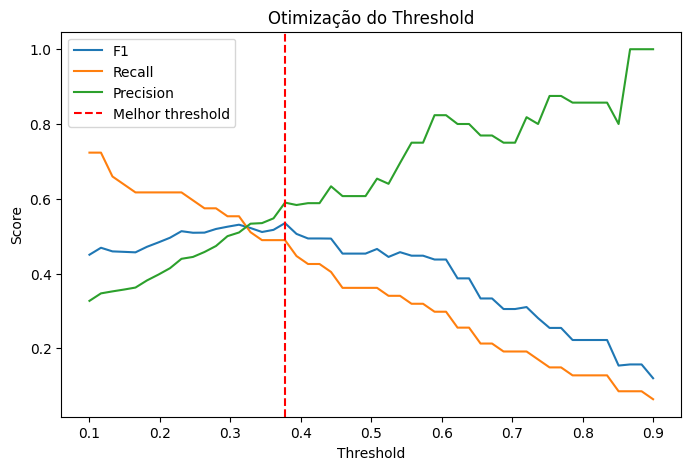

In [152]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df_thresh["threshold"], df_thresh["f1"], label="F1")
plt.plot(df_thresh["threshold"], df_thresh["recall"], label="Recall")
plt.plot(df_thresh["threshold"], df_thresh["precision"], label="Precision")

plt.axvline(best_row["threshold"], color="red", linestyle="--", label="Melhor threshold")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Otimização do Threshold")
plt.legend()
plt.show()

In [153]:
# 17. APLICAÇÃO DO THRESHOLD OTIMIZADO

best_threshold = best_row["threshold"]

y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_opt = (y_proba_test >= best_threshold).astype(int)

from sklearn.metrics import classification_report

print("===== MODELO COM THRESHOLD OTIMIZADO =====")
print(f"Threshold utilizado: {best_threshold:.3f}\n")

print(classification_report(y_test, y_pred_opt))

===== MODELO COM THRESHOLD OTIMIZADO =====
Threshold utilizado: 0.378

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       247
           1       0.59      0.49      0.53        47

    accuracy                           0.86       294
   macro avg       0.75      0.71      0.73       294
weighted avg       0.86      0.86      0.86       294



In [154]:
# 18. MÉTRICAS FINAIS COM THRESHOLD OTIMIZADO

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

best_threshold = float(best_row["threshold"])

# Probabilidades no treino e teste
y_proba_train_opt = best_model.predict_proba(X_train)[:, 1]
y_proba_test_opt  = best_model.predict_proba(X_test)[:, 1]

# Novas previsões com threshold otimizado
y_pred_train_thr = (y_proba_train_opt >= best_threshold).astype(int)
y_pred_test_thr  = (y_proba_test_opt >= best_threshold).astype(int)

# Métricas treino
r_treino_thr = {
    "acc": accuracy_score(y_train, y_pred_train_thr),
    "precision": precision_score(y_train, y_pred_train_thr),
    "recall": recall_score(y_train, y_pred_train_thr),
    "f1": f1_score(y_train, y_pred_train_thr),
    "auc": roc_auc_score(y_train, y_proba_train_opt)
}

# Métricas teste
r_teste_thr = {
    "acc": accuracy_score(y_test, y_pred_test_thr),
    "precision": precision_score(y_test, y_pred_test_thr),
    "recall": recall_score(y_test, y_pred_test_thr),
    "f1": f1_score(y_test, y_pred_test_thr),
    "auc": roc_auc_score(y_test, y_proba_test_opt)
}

print("===== MODELO OTIMIZADO + THRESHOLD OTIMIZADO =====")
print(f"Threshold ótimo: {best_threshold:.4f}\n")

print(f"{'Métrica':<12} {'Treino':>8} {'Teste':>8}")
print("-" * 32)
for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"{nome:<12} {r_treino_thr[metrica]:>8.4f} {r_teste_thr[metrica]:>8.4f}")

print("\n===== CLASSIFICATION REPORT — TESTE =====")
print(classification_report(y_test, y_pred_test_thr, target_names=["Permaneceu", "Saiu"]))

===== MODELO OTIMIZADO + THRESHOLD OTIMIZADO =====
Threshold ótimo: 0.3776

Métrica        Treino    Teste
--------------------------------
Accuracy       0.9082   0.8639
Precision      0.7440   0.5897
Recall         0.6579   0.4894
F1-Score       0.6983   0.5349
AUC-ROC        0.8821   0.8205

===== CLASSIFICATION REPORT — TESTE =====
              precision    recall  f1-score   support

  Permaneceu       0.91      0.94      0.92       247
        Saiu       0.59      0.49      0.53        47

    accuracy                           0.86       294
   macro avg       0.75      0.71      0.73       294
weighted avg       0.86      0.86      0.86       294



In [155]:
# 22. CLASSIFICAÇÃO EM CATEGORIAS DE RISCO

def classificar_risco(prob):
    if prob < 0.30:
        return "Baixo"
    elif prob < 0.50:
        return "Médio"
    elif prob < 0.70:
        return "Alto"
    else:
        return "Crítico"

df_risco["nivel_risco"] = df_risco["prob_saida"].apply(classificar_risco)

ORDEM = ["Baixo", "Médio", "Alto", "Crítico"]

contagem = df_risco["nivel_risco"].value_counts()
percentagem = df_risco["nivel_risco"].value_counts(normalize=True) * 100

print("\n===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO =====")
print(f"{'Categoria':<10} {'Contagem':>8} {'Percentagem':>12}")
print("-" * 36)

for cat in ORDEM:
    n = contagem.get(cat, 0)
    pct = percentagem.get(cat, 0.0)
    print(f"{cat:<10} {n:>8} {pct:>11.1f}%")


===== DISTRIBUIÇÃO DAS CATEGORIAS DE RISCO =====
Categoria  Contagem  Percentagem
------------------------------------
Baixo          1217        82.8%
Médio           100         6.8%
Alto             81         5.5%
Crítico          72         4.9%


In [156]:
print("===== COMPARAÇÃO FINAL =====")
print(f"{'Métrica':<12} {'Baseline':>10} {'Tuning':>10} {'Tuning+Thr':>12}")
print("-" * 46)

for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(
        f"{nome:<12} "
        f"{r_teste[metrica]:>10.4f} "
        f"{r_teste_opt[metrica]:>10.4f} "
        f"{r_teste_thr[metrica]:>12.4f}"
    )

===== COMPARAÇÃO FINAL =====
Métrica        Baseline     Tuning   Tuning+Thr
----------------------------------------------
Accuracy         0.8639     0.8673       0.8639
Precision        0.6296     0.6538       0.5897
Recall           0.3617     0.3617       0.4894
F1-Score         0.4595     0.4658       0.5349
AUC-ROC          0.8170     0.8205       0.8205


In [157]:
# 23. RESUMO FINAL — MODELO FINAL

print("=" * 60)
print("RESUMO — MODELO FINAL")
print("=" * 60)

print(f"Modelo:          Regressão Logística Otimizada")
print(f"Threshold final: {best_threshold:.4f}")
print(f"Colaboradores:   {len(df_risco)}")

print(f"\n{'Métrica':<12} {'Treino':>8} {'Teste':>8}")
print("-" * 32)
for metrica, nome in [
    ("acc", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1-Score"),
    ("auc", "AUC-ROC")
]:
    print(f"{nome:<12} {r_treino_thr[metrica]:>8.4f} {r_teste_thr[metrica]:>8.4f}")

print("\nDistribuição das categorias de risco:")
print(f"Baixo:    prob < 30%        -> {contagem.get('Baixo', 0)} colaboradores")
print(f"Médio:    30% ≤ prob < 50%  -> {contagem.get('Médio', 0)} colaboradores")
print(f"Alto:     50% ≤ prob < 70%  -> {contagem.get('Alto', 0)} colaboradores")
print(f"Crítico:  prob ≥ 70%        -> {contagem.get('Crítico', 0)} colaboradores")

print("=" * 60)

RESUMO — MODELO FINAL
Modelo:          Regressão Logística Otimizada
Threshold final: 0.3776
Colaboradores:   1470

Métrica        Treino    Teste
--------------------------------
Accuracy       0.9082   0.8639
Precision      0.7440   0.5897
Recall         0.6579   0.4894
F1-Score       0.6983   0.5349
AUC-ROC        0.8821   0.8205

Distribuição das categorias de risco:
Baixo:    prob < 30%        -> 1217 colaboradores
Médio:    30% ≤ prob < 50%  -> 100 colaboradores
Alto:     50% ≤ prob < 70%  -> 81 colaboradores
Crítico:  prob ≥ 70%        -> 72 colaboradores


In [158]:
# 24. TOP 20 COLABORADORES COM MAIOR RISCO

cols_top = ["prob_saida", "nivel_risco", "Attrition_bin"]
for col in ["Age", "MonthlyIncome", "JobLevel", "OverTime_bin"]:
    if col in df_risco.columns:
        cols_top.append(col)

top20 = df_risco.sort_values("prob_saida", ascending=False)[cols_top].head(20)

print("===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA =====")
display(top20)

===== TOP 20 — MAIOR PROBABILIDADE DE SAÍDA =====


,prob_saida,nivel_risco,Attrition_bin,Age,MonthlyIncome,JobLevel,OverTime_bin
463,0.993184,Crítico,1,26,2340,1,1
911,0.992612,Crítico,1,25,1118,1,1
1060,0.984904,Crítico,1,24,3172,1,1
457,0.981745,Crítico,1,18,1878,1,1
357,0.980088,Crítico,1,21,2174,1,1
656,0.978946,Crítico,1,32,2795,1,1
127,0.960832,Crítico,1,19,1675,1,1
171,0.953581,Crítico,1,19,2325,1,0
688,0.951764,Crítico,1,19,2121,1,1
1379,0.950460,Crítico,1,27,2863,1,0
